In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
import extinction
import h5py
import os
import subprocess
import shutil
import glob
from speclite.filters import FilterResponse
from astropy import constants as const

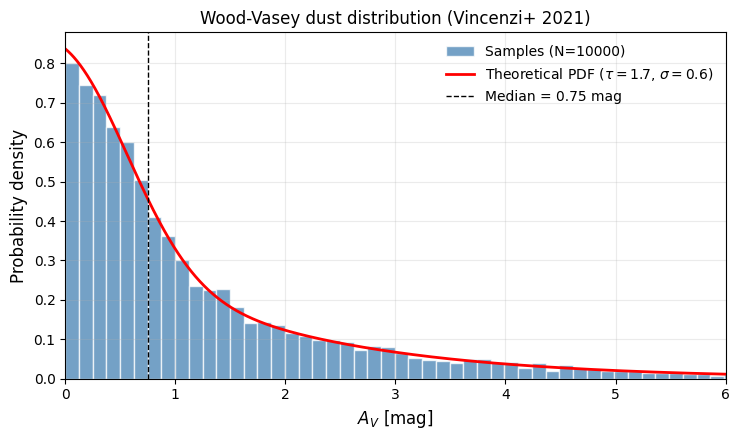

Av mean:    1.280 mag
Av median:  0.748 mag
Av p84:     2.413 mag


In [ ]:
def wood_vasey_pdf(extinction_av, exponential_amplitude=1.0, gaussian_amplitude=0.5, exponential_scale=1.7, gaussian_sigma=0.6):
    if np.isscalar(extinction_av):
        if extinction_av < 0:
            return 0.0
    else:
        extinction_av = np.asarray(extinction_av)

    exponential_term = (exponential_amplitude / exponential_scale) * np.exp(-extinction_av / exponential_scale)
    gaussian_term = (2 * gaussian_amplitude / (np.sqrt(2 * np.pi) * gaussian_sigma)) * np.exp(-extinction_av**2 / (2 * gaussian_sigma**2))
    probability = exponential_term + gaussian_term

    if not np.isscalar(extinction_av):
        probability[extinction_av < 0] = 0.0
    return probability


def sample_extinction_av(number_of_samples, exponential_scale=1.7, gaussian_sigma=0.6, av_max=10.0, grid_resolution=10000):
    av_grid = np.linspace(0, av_max, grid_resolution)
    probability_grid = wood_vasey_pdf(av_grid, exponential_scale=exponential_scale, gaussian_sigma=gaussian_sigma)
    probability_grid = probability_grid / probability_grid.sum()
    return np.random.choice(av_grid, size=number_of_samples, p=probability_grid)


def plot_av_distribution(av_samples, exponential_scale=1.7, gaussian_sigma=0.6, save_path=None):
    av_grid = np.linspace(0, 10, 10000)
    probability_grid = wood_vasey_pdf(av_grid, exponential_scale=exponential_scale, gaussian_sigma=gaussian_sigma)
    probability_normalized = probability_grid / np.trapezoid(probability_grid, av_grid)

    figure, axis = plt.subplots(figsize=(7.5, 4.5))
    axis.hist(
        av_samples,
        bins=80,
        density=True,
        color='steelblue',
        edgecolor='white',
        alpha=0.75,
        label=f'Samples (N={len(av_samples)})',
    )
    axis.plot(
        av_grid,
        probability_normalized,
        'r-',
        lw=2.0,
        label=fr'Theoretical PDF ($\tau={exponential_scale}$, $\sigma={gaussian_sigma}$)',
    )
    axis.axvline(
        np.median(av_samples),
        color='k',
        ls='--',
        lw=1.0,
        label=fr'Median = {np.median(av_samples):.2f} mag',
    )
    axis.set_xlabel(r'$A_V$ [mag]', fontsize=12)
    axis.set_ylabel('Probability density', fontsize=12)
    axis.set_title('Wood-Vasey dust distribution (Vincenzi+ 2021)', fontsize=12)
    axis.legend(frameon=False, fontsize=10)
    axis.set_xlim(0, 6)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def generate_av_samples(number_of_samples=10000, exponential_scale=1.7, gaussian_sigma=0.6, plot=True, save_path=None):
    av_samples = sample_extinction_av(
        number_of_samples,
        exponential_scale=exponential_scale,
        gaussian_sigma=gaussian_sigma,
    )

    if plot:
        plot_av_distribution(
            av_samples,
            exponential_scale=exponential_scale,
            gaussian_sigma=gaussian_sigma,
            save_path=save_path,
        )
        print(f'Av mean:    {av_samples.mean():.3f} mag')
        print(f'Av median:  {np.median(av_samples):.3f} mag')
        print(f'Av p84:     {np.percentile(av_samples, 84):.3f} mag')

    return av_samples


Av_samples = generate_av_samples(
    number_of_samples=10000,
    exponential_scale=1.7,
    gaussian_sigma=0.6,
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/Av_distribution.png',
)


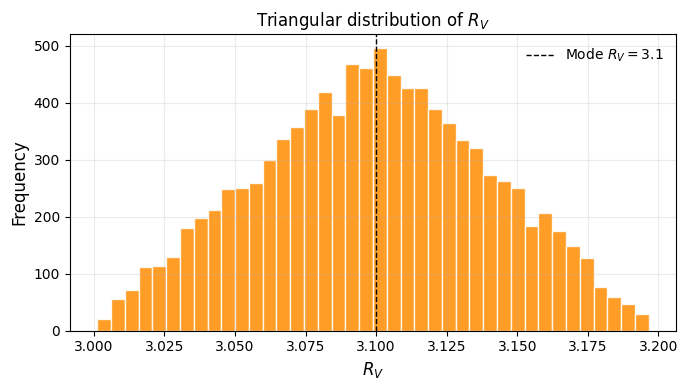

In [ ]:
def sample_extinction_rv(number_of_samples, left=3.0, mode=3.1, right=3.2):
    return np.random.triangular(left=left, mode=mode, right=right, size=number_of_samples)


def plot_rv_distribution(rv_samples, mode=3.1):
    figure, axis = plt.subplots(figsize=(7, 4))
    axis.hist(rv_samples, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
    axis.axvline(mode, color='k', ls='--', lw=1.0, label=fr'Mode $R_V = {mode}$')
    axis.set_xlabel(r'$R_V$', fontsize=12)
    axis.set_ylabel('Frequency', fontsize=12)
    axis.set_title(r'Triangular distribution of $R_V$', fontsize=12)
    axis.legend(frameon=False)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def generate_rv_samples(number_of_samples=10000, left=3.0, mode=3.1, right=3.2, plot=True):
    rv_samples = sample_extinction_rv(number_of_samples, left=left, mode=mode, right=right)
    if plot:
        plot_rv_distribution(rv_samples, mode=mode)
    return rv_samples


RV_samples = generate_rv_samples(number_of_samples=10000, plot=True)


In [ ]:
def download_kasen_kilonova_model(
    model_file='kasen_kn.h5',
    repository_url='https://github.com/dnkasen/Kasen_Kilonova_Models_2017.git',
    subdirectory='systematic_kilonova_model_grid',
):
    if os.path.exists(model_file):
        print(f'Model already exists: {model_file}')
        return model_file

    print('Downloading Kasen+2017 KN model via git sparse-checkout...')
    subprocess.run(
        ['git', 'clone', '--depth', '1', '--filter=blob:none', '--no-checkout', repository_url, 'kasen_repo'],
        check=True,
    )
    subprocess.run(
        ['git', '-C', 'kasen_repo', 'sparse-checkout', 'set', subdirectory],
        check=True,
    )
    subprocess.run(['git', '-C', 'kasen_repo', 'checkout'], check=True)

    available_files = glob.glob(f'kasen_repo/{subdirectory}/*.h5')
    print(f'Available files: {[os.path.basename(file_path) for file_path in available_files[:5]]}')

    shutil.copy(available_files[0], model_file)
    shutil.rmtree('kasen_repo')
    print(f'Model saved: {os.path.basename(available_files[0])}')
    return model_file


MODEL_FILE = download_kasen_kilonova_model()


Model already exists: kasen_kn.h5


Time range: -1.95 – 24.95 days
Closest phase: 1.45 days (requested: 1.5 d)
Flux peak at 10 pc: 1.032e-03 erg s^-1 cm^-2 Å^-1


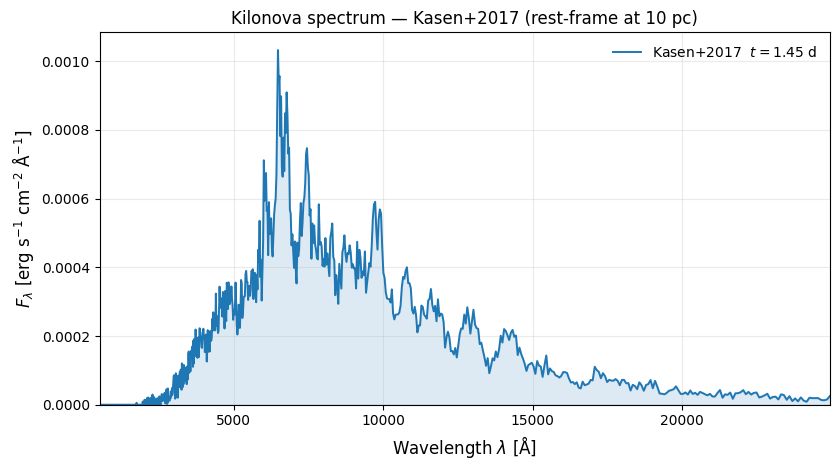

In [ ]:
def read_kasen_spectrum(
    model_file,
    target_phase_days=1.5,
    wavelength_min=500.0,
    wavelength_max=25000.0,
    distance_parsec=10.0,
):
    speed_of_light_angstrom_per_second = const.c.to(u.AA / u.s).value
    distance_cm = (distance_parsec * u.pc).to(u.cm).value
    surface_factor = 4.0 * np.pi * distance_cm**2

    with h5py.File(model_file, 'r') as file_handle:
        frequency = file_handle['nu'][:]
        time_array = file_handle['time'][:]
        luminosity_nu = file_handle['Lnu'][:]

    if time_array[-1] > 1000:
        time_days = time_array / 86400.0
    else:
        time_days = time_array

    wavelength = speed_of_light_angstrom_per_second / frequency
    sort_index = np.argsort(wavelength)
    wavelength = wavelength[sort_index]
    frequency_sorted = frequency[sort_index]

    phase_index = np.argmin(np.abs(time_days - target_phase_days))
    actual_phase_days = time_days[phase_index]

    luminosity_lambda = luminosity_nu[phase_index, sort_index] * frequency_sorted**2 / speed_of_light_angstrom_per_second
    flux_lambda = luminosity_lambda / surface_factor
    flux_lambda = np.maximum(flux_lambda, 0)

    wavelength_mask = (wavelength >= wavelength_min) & (wavelength <= wavelength_max)
    wavelength = wavelength[wavelength_mask]
    flux_lambda = flux_lambda[wavelength_mask]

    return wavelength, flux_lambda, actual_phase_days, time_days


def plot_kilonova_spectrum(wavelength, flux_lambda, phase_days, distance_parsec=10.0, label_prefix='Kasen+2017'):
    figure, axis = plt.subplots(figsize=(8.5, 4.8))
    axis.plot(wavelength, flux_lambda, color='C0', lw=1.4, label=fr'{label_prefix}  $t={phase_days:.2f}$ d')
    axis.fill_between(wavelength, 0, flux_lambda, color='C0', alpha=0.15)
    axis.set_xlabel(r'Wavelength $\lambda$ [Å]', fontsize=12)
    axis.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis.set_title(
        fr'Kilonova spectrum — Kasen+2017 (rest-frame at {distance_parsec:.0f} pc)',
        fontsize=12,
    )
    axis.set_xlim(wavelength.min(), wavelength.max())
    axis.set_ylim(bottom=0)
    axis.legend(frameon=False, fontsize=10)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def load_kilonova_spectrum(model_file, target_phase_days=1.5, distance_parsec=10.0, plot=True):
    wavelength, flux_lambda, actual_phase_days, time_days = read_kasen_spectrum(
        model_file,
        target_phase_days=target_phase_days,
        distance_parsec=distance_parsec,
    )
    if plot:
        print(f'Time range: {time_days[0]:.2f} – {time_days[-1]:.2f} days')
        print(f'Closest phase: {actual_phase_days:.2f} days (requested: {target_phase_days} d)')
        print(f'Flux peak at {distance_parsec:.0f} pc: {flux_lambda.max():.3e} erg s^-1 cm^-2 Å^-1')
        plot_kilonova_spectrum(wavelength, flux_lambda, actual_phase_days, distance_parsec=distance_parsec)
    return wavelength, flux_lambda, actual_phase_days


wave_kn, flux_kn, kn_phase_days = load_kilonova_spectrum(
    MODEL_FILE,
    target_phase_days=1.5,
    distance_parsec=10.0,
    plot=True,
)


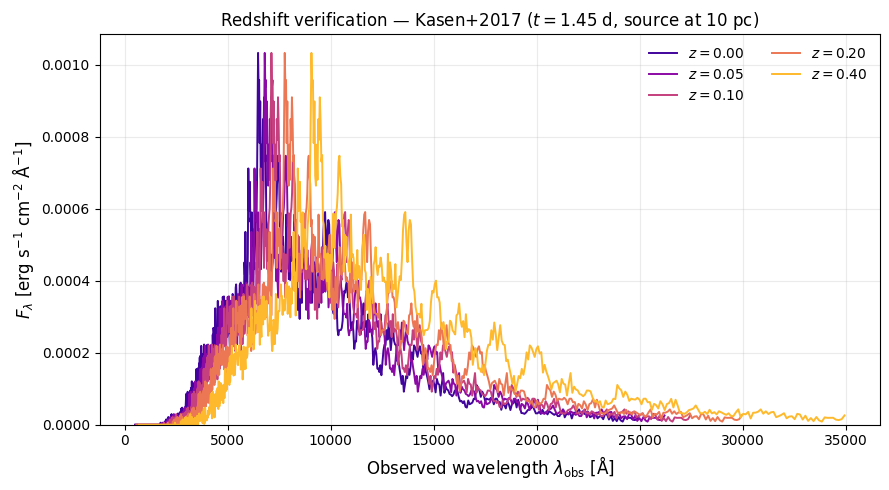

Rest-frame peak wavelength: 6475.0 Å
  z=0.00 → expected peak = 6475.0 Å
  z=0.05 → expected peak = 6798.7 Å
  z=0.10 → expected peak = 7122.5 Å
  z=0.20 → expected peak = 7770.0 Å
  z=0.40 → expected peak = 9065.0 Å


In [ ]:
from specutils import Spectrum


def shift_spectrum_to_redshift(rest_wavelength, rest_flux_lambda, redshift):
    spectrum_rest = Spectrum(
        spectral_axis=rest_wavelength * u.AA,
        flux=rest_flux_lambda * u.Unit('erg / (s cm2 AA)'),
    )
    spectrum_redshifted = Spectrum(
        spectral_axis=spectrum_rest.spectral_axis,
        flux=spectrum_rest.flux,
    )
    spectrum_redshifted.shift_spectrum_to(redshift=redshift)
    observed_wavelength = spectrum_redshifted.spectral_axis.to(u.AA).value
    observed_flux_lambda = spectrum_redshifted.flux.value
    return observed_wavelength, observed_flux_lambda


def plot_redshift_verification(rest_wavelength, rest_flux_lambda, redshift_list, phase_days):
    figure, axis = plt.subplots(figsize=(9, 5))
    colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(redshift_list)))

    for redshift, color in zip(redshift_list, colors):
        observed_wavelength, observed_flux_lambda = shift_spectrum_to_redshift(
            rest_wavelength, rest_flux_lambda, redshift,
        )
        axis.plot(observed_wavelength, observed_flux_lambda, color=color, lw=1.4, label=fr'$z = {redshift:.2f}$')

    axis.set_xlabel(r'Observed wavelength $\lambda_{\rm obs}$ [Å]', fontsize=12)
    axis.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis.set_title(
        fr'Redshift verification — Kasen+2017 ($t = {phase_days:.2f}$ d, source at 10 pc)',
        fontsize=12,
    )
    axis.set_ylim(bottom=0)
    axis.legend(frameon=False, fontsize=10, ncol=2)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def verify_redshift_shift(
    rest_wavelength,
    rest_flux_lambda,
    phase_days,
    redshift_list=(0.0, 0.05, 0.1, 0.2, 0.4),
    plot=True,
):
    peak_index = np.argmax(rest_flux_lambda)
    rest_peak_wavelength = rest_wavelength[peak_index]

    expected_peaks = {}
    for redshift in redshift_list:
        expected_peaks[redshift] = rest_peak_wavelength * (1 + redshift)

    if plot:
        plot_redshift_verification(rest_wavelength, rest_flux_lambda, redshift_list, phase_days)
        print(f'Rest-frame peak wavelength: {rest_peak_wavelength:.1f} Å')
        for redshift, expected_peak in expected_peaks.items():
            print(f'  z={redshift:.2f} → expected peak = {expected_peak:.1f} Å')

    return expected_peaks


redshift_expected_peaks = verify_redshift_shift(
    wave_kn,
    flux_kn,
    phase_days=kn_phase_days,
    redshift_list=(0.0, 0.05, 0.1, 0.2, 0.4),
    plot=True,
)


/var/folders/b0/_shrs6sx2x5gt6jg55ztqpdr0000gn/T/ipykernel_52706/2860426814.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


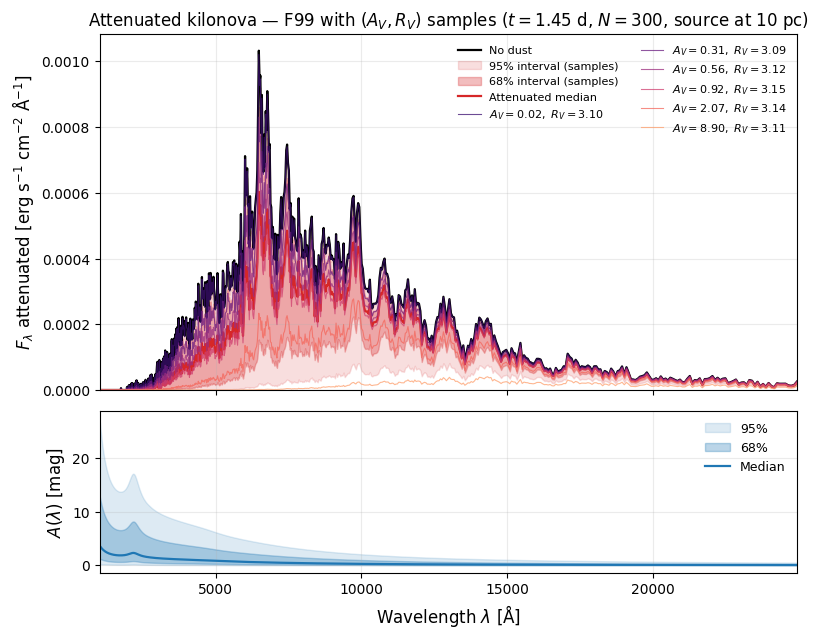

Av used:  median=0.75  range=[0.02, 8.90]
Rv used:  median=3.10  range=[3.01, 3.20]


In [ ]:
from dust_extinction.parameter_averages import F99


def apply_extinction_samples(
    wavelength,
    flux_lambda,
    av_samples,
    rv_samples,
    valid_wavelength_range=(1000.0, 33333.0),
    number_of_draws=300,
    random_seed=42,
):
    random_generator = np.random.default_rng(random_seed)
    sample_indices = random_generator.choice(len(av_samples), size=number_of_draws, replace=False)
    av_drawn = av_samples[sample_indices]
    rv_drawn = rv_samples[sample_indices]

    valid_mask = (wavelength >= valid_wavelength_range[0]) & (wavelength <= valid_wavelength_range[1])
    wavelength_valid = wavelength[valid_mask]
    flux_valid = flux_lambda[valid_mask]
    wavelength_quantity = wavelength_valid * u.AA

    attenuated_matrix = np.empty((number_of_draws, wavelength_valid.size))
    extinction_matrix = np.empty_like(attenuated_matrix)

    for draw_index, (av_value, rv_value) in enumerate(zip(av_drawn, rv_drawn)):
        extinction_model = F99(Rv=float(rv_value))
        transmission = extinction_model.extinguish(wavelength_quantity, Av=float(av_value))
        attenuated_matrix[draw_index] = flux_valid * transmission
        extinction_matrix[draw_index] = -2.5 * np.log10(transmission)

    return {
        'wavelength_valid': wavelength_valid,
        'flux_valid': flux_valid,
        'attenuated_matrix': attenuated_matrix,
        'extinction_matrix': extinction_matrix,
        'av_drawn': av_drawn,
        'rv_drawn': rv_drawn,
    }


def plot_attenuated_kilonova(extinction_result, phase_days, save_path=None):
    wavelength_valid = extinction_result['wavelength_valid']
    flux_valid = extinction_result['flux_valid']
    attenuated_matrix = extinction_result['attenuated_matrix']
    extinction_matrix = extinction_result['extinction_matrix']
    av_drawn = extinction_result['av_drawn']
    rv_drawn = extinction_result['rv_drawn']
    number_of_draws = attenuated_matrix.shape[0]

    median_attenuated = np.median(attenuated_matrix, axis=0)
    p16_attenuated = np.percentile(attenuated_matrix, 16, axis=0)
    p84_attenuated = np.percentile(attenuated_matrix, 84, axis=0)
    p025_attenuated = np.percentile(attenuated_matrix, 2.5, axis=0)
    p975_attenuated = np.percentile(attenuated_matrix, 97.5, axis=0)

    sort_order = np.argsort(av_drawn)
    sample_indices = sort_order[np.linspace(0, number_of_draws - 1, 6).astype(int)]

    figure, (axis_top, axis_bottom) = plt.subplots(
        2, 1,
        figsize=(9, 7),
        sharex=True,
        gridspec_kw={'hspace': 0.08, 'height_ratios': [2.2, 1]},
    )

    axis_top.plot(wavelength_valid, flux_valid, color='k', lw=1.6, label='No dust')
    axis_top.fill_between(
        wavelength_valid, p025_attenuated, p975_attenuated,
        color='C3', alpha=0.15, label='95% interval (samples)',
    )
    axis_top.fill_between(
        wavelength_valid, p16_attenuated, p84_attenuated,
        color='C3', alpha=0.30, label='68% interval (samples)',
    )
    axis_top.plot(wavelength_valid, median_attenuated, color='C3', lw=1.6, label='Attenuated median')

    colors = plt.cm.magma(np.linspace(0.2, 0.8, len(sample_indices)))
    for draw_index, color in zip(sample_indices, colors):
        axis_top.plot(
            wavelength_valid,
            attenuated_matrix[draw_index],
            color=color,
            lw=0.8,
            alpha=0.75,
            label=fr'$A_V={av_drawn[draw_index]:.2f},\ R_V={rv_drawn[draw_index]:.2f}$',
        )

    axis_top.set_ylabel(r'$F_\lambda$ attenuated [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis_top.set_title(
        fr'Attenuated kilonova — F99 with $(A_V, R_V)$ samples '
        fr'($t={phase_days:.2f}$ d, $N={number_of_draws}$, source at 10 pc)',
        fontsize=12,
    )
    axis_top.set_ylim(bottom=0)
    axis_top.legend(frameon=False, fontsize=8, loc='upper right', ncol=2)
    axis_top.grid(alpha=0.25)

    axis_bottom.fill_between(
        wavelength_valid,
        np.percentile(extinction_matrix, 2.5, axis=0),
        np.percentile(extinction_matrix, 97.5, axis=0),
        color='C0', alpha=0.15, label='95%',
    )
    axis_bottom.fill_between(
        wavelength_valid,
        np.percentile(extinction_matrix, 16, axis=0),
        np.percentile(extinction_matrix, 84, axis=0),
        color='C0', alpha=0.30, label='68%',
    )
    axis_bottom.plot(
        wavelength_valid,
        np.median(extinction_matrix, axis=0),
        color='C0', lw=1.6, label='Median',
    )

    axis_bottom.set_xlabel(r'Wavelength $\lambda$ [Å]', fontsize=12)
    axis_bottom.set_ylabel(r'$A(\lambda)$ [mag]', fontsize=12)
    axis_bottom.set_xlim(wavelength_valid.min(), wavelength_valid.max())
    axis_bottom.legend(frameon=False, fontsize=9, loc='upper right')
    axis_bottom.grid(alpha=0.25)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def attenuate_kilonova_with_samples(
    wavelength,
    flux_lambda,
    av_samples,
    rv_samples,
    phase_days,
    number_of_draws=300,
    random_seed=42,
    plot=True,
    save_path=None,
):
    extinction_result = apply_extinction_samples(
        wavelength,
        flux_lambda,
        av_samples,
        rv_samples,
        number_of_draws=number_of_draws,
        random_seed=random_seed,
    )

    if plot:
        plot_attenuated_kilonova(extinction_result, phase_days=phase_days, save_path=save_path)
        av_drawn = extinction_result['av_drawn']
        rv_drawn = extinction_result['rv_drawn']
        print(f'Av used:  median={np.median(av_drawn):.2f}  range=[{av_drawn.min():.2f}, {av_drawn.max():.2f}]')
        print(f'Rv used:  median={np.median(rv_drawn):.2f}  range=[{rv_drawn.min():.2f}, {rv_drawn.max():.2f}]')

    return extinction_result


extinction_result = attenuate_kilonova_with_samples(
    wave_kn,
    flux_kn,
    Av_samples,
    RV_samples,
    phase_days=kn_phase_days,
    number_of_draws=300,
    random_seed=42,
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/kn_spectrum_extinction.png',
)


/opt/anaconda3/envs/kilonova/lib/python3.14/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /Users/bhianca/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


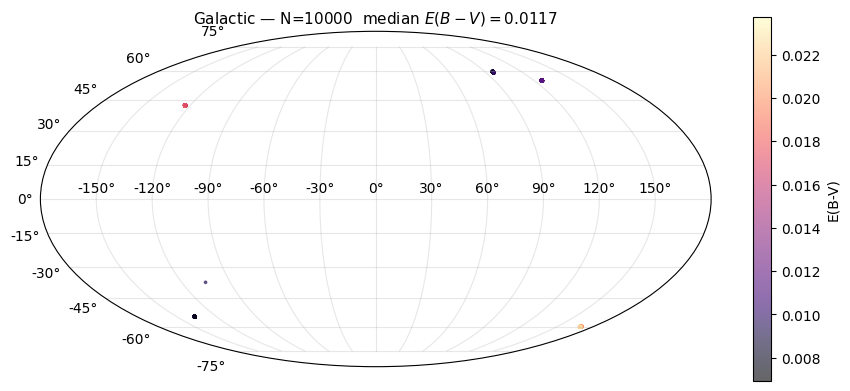

  parquet rows=64343  unique=34393  duplicates=29950
  sampled N=10000  E(B-V) median=0.0117  p84=0.0206  max=0.0237


In [ ]:
import pandas as pd
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery

MILKY_WAY_RV = 3.1
HOURGLASS_OBJECTS_PATH = '/Users/bhianca/Downloads/hourglass_objects.parquet'
HOURGLASS_PHOTOMETRY_PATH = '/Users/bhianca/Downloads/hourglass_photometry.parquet'


def sample_hourglass_ebv(
    parquet_path=HOURGLASS_OBJECTS_PATH,
    number_of_samples=10000,
    random_seed=123,
    plot=True,
    save_path=None,
):
    hourglass_table = pd.read_parquet(parquet_path, columns=['ra', 'dec'])
    unique_table = hourglass_table.drop_duplicates(subset=['ra', 'dec']).reset_index(drop=True)
    number_of_duplicates = len(hourglass_table) - len(unique_table)

    random_generator = np.random.default_rng(random_seed)
    sample_size = min(number_of_samples, len(unique_table))
    sample_indices = random_generator.choice(len(unique_table), size=sample_size, replace=False)

    ra_deg = unique_table['ra'].to_numpy()[sample_indices]
    dec_deg = unique_table['dec'].to_numpy()[sample_indices]
    sky_coordinates = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
    ebv_samples = SFDQuery()(sky_coordinates)

    hourglass_sampling = {
        'ebv_samples': ebv_samples,
        'ra_deg': ra_deg,
        'dec_deg': dec_deg,
        'galactic_longitudes_deg': sky_coordinates.galactic.l.deg,
        'galactic_latitudes_deg': sky_coordinates.galactic.b.deg,
        'number_of_unique_coordinates': len(unique_table),
        'number_of_duplicates_in_parquet': number_of_duplicates,
    }

    if plot:
        plot_hourglass_positions(hourglass_sampling, save_path=save_path)
        print(f'  parquet rows={len(hourglass_table)}  unique={len(unique_table)}  '
              f'duplicates={number_of_duplicates}')
        print(f'  sampled N={sample_size}  E(B-V) median={np.median(ebv_samples):.4f}  '
              f'p84={np.percentile(ebv_samples, 84):.4f}  max={ebv_samples.max():.4f}')

    return hourglass_sampling


def plot_hourglass_positions(hourglass_sampling, save_path=None):
    galactic_longitudes_deg = hourglass_sampling['galactic_longitudes_deg']
    galactic_latitudes_deg = hourglass_sampling['galactic_latitudes_deg']
    ebv_samples = hourglass_sampling['ebv_samples']

    figure, axis_galactic = plt.subplots(
        figsize=(9, 5.5), subplot_kw={'projection': 'mollweide'},
    )

    galactic_longitudes_radians = np.deg2rad(np.where(
        galactic_longitudes_deg > 180.0,
        galactic_longitudes_deg - 360.0,
        galactic_longitudes_deg,
    ))

    scatter_gal = axis_galactic.scatter(
        galactic_longitudes_radians, np.deg2rad(galactic_latitudes_deg),
        c=ebv_samples, s=3, alpha=0.6, cmap='magma',
    )
    plt.colorbar(scatter_gal, ax=axis_galactic, label='E(B-V)', shrink=0.7)
    axis_galactic.set_title(
        fr'Galactic — N={ebv_samples.size}  median $E(B-V)={np.median(ebv_samples):.4f}$',
        fontsize=11,
    )
    axis_galactic.grid(alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


hltds_sampling = sample_hourglass_ebv(
    parquet_path=HOURGLASS_OBJECTS_PATH,
    number_of_samples=10000,
    random_seed=123,
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/hourglass_ebv_positions.png',
)


/var/folders/b0/_shrs6sx2x5gt6jg55ztqpdr0000gn/T/ipykernel_52706/3110957810.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


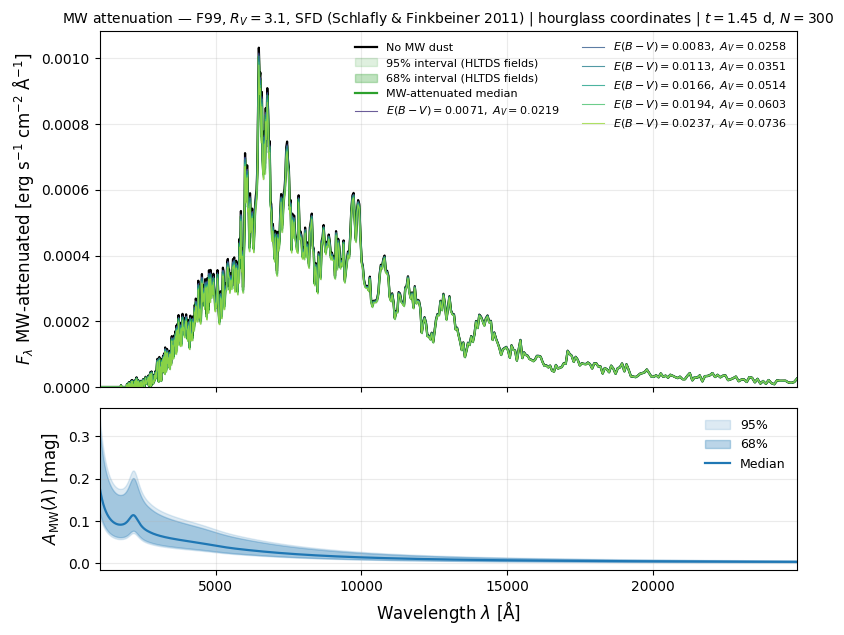

Drawn A_V (Rv=3.1): median=0.0370  range=[0.0219, 0.0736]


In [ ]:
def apply_milky_way_extinction(
    wavelength,
    flux_lambda,
    ebv_samples,
    rv_milky_way=MILKY_WAY_RV,
    valid_wavelength_range=(1000.0, 33333.0),
    number_of_draws=300,
    random_seed=42,
):
    random_generator = np.random.default_rng(random_seed)
    sample_indices = random_generator.choice(len(ebv_samples), size=number_of_draws, replace=False)
    ebv_drawn = ebv_samples[sample_indices]
    av_drawn = rv_milky_way * ebv_drawn

    valid_mask = (wavelength >= valid_wavelength_range[0]) & (wavelength <= valid_wavelength_range[1])
    wavelength_valid = wavelength[valid_mask]
    flux_valid = flux_lambda[valid_mask]
    wavelength_quantity = wavelength_valid * u.AA

    extinction_model = F99(Rv=rv_milky_way)
    attenuated_matrix = np.empty((number_of_draws, wavelength_valid.size))
    extinction_matrix = np.empty_like(attenuated_matrix)

    for draw_index, av_value in enumerate(av_drawn):
        transmission = extinction_model.extinguish(wavelength_quantity, Av=float(av_value))
        attenuated_matrix[draw_index] = flux_valid * transmission
        extinction_matrix[draw_index] = -2.5 * np.log10(transmission)

    return {
        'wavelength_valid': wavelength_valid,
        'flux_valid': flux_valid,
        'attenuated_matrix': attenuated_matrix,
        'extinction_matrix': extinction_matrix,
        'ebv_drawn': ebv_drawn,
        'av_drawn': av_drawn,
        'sample_indices': sample_indices,
        'rv_milky_way': rv_milky_way,
    }


def plot_milky_way_attenuation(milky_way_result, phase_days, save_path=None):
    wavelength_valid = milky_way_result['wavelength_valid']
    flux_valid = milky_way_result['flux_valid']
    attenuated_matrix = milky_way_result['attenuated_matrix']
    extinction_matrix = milky_way_result['extinction_matrix']
    ebv_drawn = milky_way_result['ebv_drawn']
    av_drawn = milky_way_result['av_drawn']
    rv_milky_way = milky_way_result['rv_milky_way']
    number_of_draws = attenuated_matrix.shape[0]

    median_attenuated = np.median(attenuated_matrix, axis=0)
    p16_attenuated = np.percentile(attenuated_matrix, 16, axis=0)
    p84_attenuated = np.percentile(attenuated_matrix, 84, axis=0)
    p025_attenuated = np.percentile(attenuated_matrix, 2.5, axis=0)
    p975_attenuated = np.percentile(attenuated_matrix, 97.5, axis=0)

    sort_order = np.argsort(av_drawn)
    sample_indices = sort_order[np.linspace(0, number_of_draws - 1, 6).astype(int)]

    figure, (axis_top, axis_bottom) = plt.subplots(
        2, 1,
        figsize=(9, 7),
        sharex=True,
        gridspec_kw={'hspace': 0.08, 'height_ratios': [2.2, 1]},
    )

    axis_top.plot(wavelength_valid, flux_valid, color='k', lw=1.6, label='No MW dust')
    axis_top.fill_between(
        wavelength_valid, p025_attenuated, p975_attenuated,
        color='C2', alpha=0.15, label='95% interval (HLTDS fields)',
    )
    axis_top.fill_between(
        wavelength_valid, p16_attenuated, p84_attenuated,
        color='C2', alpha=0.30, label='68% interval (HLTDS fields)',
    )
    axis_top.plot(wavelength_valid, median_attenuated, color='C2', lw=1.6, label='MW-attenuated median')

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(sample_indices)))
    for draw_index, color in zip(sample_indices, colors):
        axis_top.plot(
            wavelength_valid,
            attenuated_matrix[draw_index],
            color=color,
            lw=0.8,
            alpha=0.8,
            label=fr'$E(B-V)={ebv_drawn[draw_index]:.4f},\ A_V={av_drawn[draw_index]:.4f}$',
        )

    axis_top.set_ylabel(r'$F_\lambda$ MW-attenuated [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis_top.set_title(
        fr'MW attenuation — F99, $R_V={rv_milky_way}$, SFD (Schlafly & Finkbeiner 2011) '
        fr'| hourglass coordinates | $t={phase_days:.2f}$ d, $N={number_of_draws}$',
        fontsize=10,
    )
    axis_top.set_ylim(bottom=0)
    axis_top.legend(frameon=False, fontsize=8, loc='upper right', ncol=2)
    axis_top.grid(alpha=0.25)

    axis_bottom.fill_between(
        wavelength_valid,
        np.percentile(extinction_matrix, 2.5, axis=0),
        np.percentile(extinction_matrix, 97.5, axis=0),
        color='C0', alpha=0.15, label='95%',
    )
    axis_bottom.fill_between(
        wavelength_valid,
        np.percentile(extinction_matrix, 16, axis=0),
        np.percentile(extinction_matrix, 84, axis=0),
        color='C0', alpha=0.30, label='68%',
    )
    axis_bottom.plot(
        wavelength_valid,
        np.median(extinction_matrix, axis=0),
        color='C0', lw=1.6, label='Median',
    )

    axis_bottom.set_xlabel(r'Wavelength $\lambda$ [Å]', fontsize=12)
    axis_bottom.set_ylabel(r'$A_{\rm MW}(\lambda)$ [mag]', fontsize=12)
    axis_bottom.set_xlim(wavelength_valid.min(), wavelength_valid.max())
    axis_bottom.legend(frameon=False, fontsize=9, loc='upper right')
    axis_bottom.grid(alpha=0.25)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def attenuate_kilonova_with_milky_way(
    wavelength,
    flux_lambda,
    phase_days,
    hltds_sampling,
    rv_milky_way=MILKY_WAY_RV,
    number_of_draws=300,
    random_seed=42,
    plot=True,
    save_path=None,
):
    ebv_samples = hltds_sampling['ebv_samples']

    milky_way_result = apply_milky_way_extinction(
        wavelength,
        flux_lambda,
        ebv_samples,
        rv_milky_way=rv_milky_way,
        number_of_draws=number_of_draws,
        random_seed=random_seed,
    )
    milky_way_result['hltds_sampling'] = hltds_sampling

    if plot:
        plot_milky_way_attenuation(
            milky_way_result,
            phase_days=phase_days,
            save_path=save_path,
        )
        av_drawn = milky_way_result['av_drawn']
        print(f'Drawn A_V (Rv={rv_milky_way}): median={np.median(av_drawn):.4f}  '
              f'range=[{av_drawn.min():.4f}, {av_drawn.max():.4f}]')

    return milky_way_result


milky_way_result = attenuate_kilonova_with_milky_way(
    wave_kn,
    flux_kn,
    phase_days=kn_phase_days,
    hltds_sampling=hltds_sampling,
    rv_milky_way=3.1,
    number_of_draws=300,
    random_seed=42,
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/kn_milky_way_extinction.png',
)


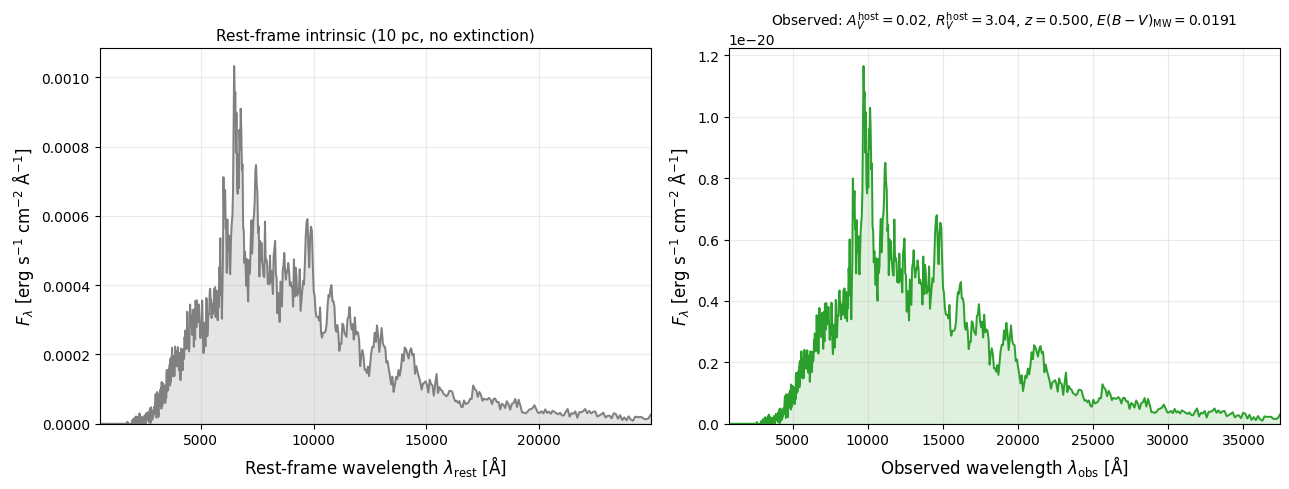

Host:      Av=0.024  Rv=3.039
Redshift:  z=0.5000  d_L=2.920e+09 pc
MW:        E(B-V)=0.0191  Av=0.0594  Rv=3.1


In [ ]:
from astropy.cosmology import Planck18

F99_VALID_RANGE = (1000.0, 33333.0)

FLUX_UNIT = u.Unit('erg / (s cm2 AA)')


def flux_lambda_to_ab_magnitude(wavelength_angstrom, flux_lambda):
    speed_of_light_angstrom_per_second = const.c.to(u.AA / u.s).value
    flux_nu = flux_lambda * wavelength_angstrom**2 / speed_of_light_angstrom_per_second
    flux_nu_safe = np.where(flux_nu > 0, flux_nu, np.nan)
    return -2.5 * np.log10(flux_nu_safe) - 48.6


def ab_magnitude_to_flux_lambda(wavelength_angstrom, magnitude_ab):
    speed_of_light_angstrom_per_second = const.c.to(u.AA / u.s).value
    flux_nu = 10.0**(-(magnitude_ab + 48.6) / 2.5)
    return flux_nu * speed_of_light_angstrom_per_second / wavelength_angstrom**2


def apply_dust_extinction_within_valid_range(
    wavelength_angstrom,
    flux_lambda,
    extinction_av,
    extinction_rv,
    valid_range=F99_VALID_RANGE,
):
    extinction_model = F99(Rv=float(extinction_rv))
    transmission = np.ones_like(wavelength_angstrom, dtype=float)
    valid_mask = (
        (wavelength_angstrom >= valid_range[0])
        & (wavelength_angstrom <= valid_range[1])
    )
    if valid_mask.any():
        transmission[valid_mask] = extinction_model.extinguish(
            wavelength_angstrom[valid_mask] * u.AA, Av=float(extinction_av),
        )
    return flux_lambda * transmission


def generate_observed_kilonova_spectrum(
    wavelength_rest,
    spectrum_input,
    extinction_av_host,
    extinction_rv_host,
    redshift,
    ebv_milky_way,
    rv_milky_way=MILKY_WAY_RV,
    intrinsic_distance_parsec=10.0,
    luminosity_distance_parsec=None,
    cosmology=Planck18,
    input_mode='flux',
    output_mode='flux',
    plot=True,
    save_path=None,
):
    wavelength_rest = np.asarray(wavelength_rest, dtype=float)
    if input_mode == 'flux':
        rest_flux_lambda = np.asarray(spectrum_input, dtype=float)
    elif input_mode == 'magnitude':
        rest_flux_lambda = ab_magnitude_to_flux_lambda(wavelength_rest, np.asarray(spectrum_input, dtype=float))
    else:
        raise ValueError(f'unknown input_mode: {input_mode!r}')

    flux_after_host_extinction = apply_dust_extinction_within_valid_range(
        wavelength_rest,
        rest_flux_lambda,
        extinction_av=extinction_av_host,
        extinction_rv=extinction_rv_host,
    )

    wavelength_observed, flux_after_redshift_at_intrinsic_distance = shift_spectrum_to_redshift(
        wavelength_rest,
        flux_after_host_extinction,
        redshift,
    )

    if luminosity_distance_parsec is None:
        if redshift > 0:
            luminosity_distance_parsec = cosmology.luminosity_distance(redshift).to(u.pc).value
        else:
            luminosity_distance_parsec = intrinsic_distance_parsec

    distance_dimming_factor = (intrinsic_distance_parsec / luminosity_distance_parsec)**2
    flux_after_distance_dimming = flux_after_redshift_at_intrinsic_distance * distance_dimming_factor

    extinction_av_milky_way = rv_milky_way * ebv_milky_way
    flux_after_milky_way_extinction = apply_dust_extinction_within_valid_range(
        np.asarray(wavelength_observed, dtype=float),
        flux_after_distance_dimming,
        extinction_av=extinction_av_milky_way,
        extinction_rv=rv_milky_way,
    )

    if output_mode == 'flux':
        spectrum_output = flux_after_milky_way_extinction * FLUX_UNIT
    elif output_mode == 'magnitude':
        spectrum_output = flux_lambda_to_ab_magnitude(wavelength_observed, flux_after_milky_way_extinction)
    else:
        raise ValueError(f'unknown output_mode: {output_mode!r}')

    pipeline_result = {
        'wavelength_observed': wavelength_observed * u.AA,
        'spectrum_output': spectrum_output,
        'output_mode': output_mode,
        'flux_observed': flux_after_milky_way_extinction * FLUX_UNIT,
        'wavelength_rest': wavelength_rest * u.AA,
        'flux_rest_intrinsic': rest_flux_lambda * FLUX_UNIT,
        'parameters': {
            'extinction_av_host': extinction_av_host,
            'extinction_rv_host': extinction_rv_host,
            'redshift': redshift,
            'ebv_milky_way': ebv_milky_way,
            'rv_milky_way': rv_milky_way,
            'extinction_av_milky_way': extinction_av_milky_way,
            'intrinsic_distance_parsec': intrinsic_distance_parsec,
            'luminosity_distance_parsec': luminosity_distance_parsec,
        },
    }

    if plot:
        plot_observed_kilonova_spectrum(pipeline_result, save_path=save_path)
        parameters = pipeline_result['parameters']
        print(f'Host:      Av={parameters["extinction_av_host"]:.3f}  Rv={parameters["extinction_rv_host"]:.3f}')
        print(f'Redshift:  z={parameters["redshift"]:.4f}  d_L={parameters["luminosity_distance_parsec"]:.3e} pc')
        print(f'MW:        E(B-V)={parameters["ebv_milky_way"]:.4f}  Av={parameters["extinction_av_milky_way"]:.4f}  Rv={parameters["rv_milky_way"]}')

    return pipeline_result


def plot_observed_kilonova_spectrum(pipeline_result, save_path=None):
    parameters = pipeline_result['parameters']
    wavelength_observed = pipeline_result['wavelength_observed'].to(u.AA).value
    flux_observed = pipeline_result['flux_observed'].value
    wavelength_rest = pipeline_result['wavelength_rest'].to(u.AA).value
    flux_rest_intrinsic = pipeline_result['flux_rest_intrinsic'].value

    figure, (axis_left, axis_right) = plt.subplots(1, 2, figsize=(13, 5))

    axis_left.plot(wavelength_rest, flux_rest_intrinsic, color='gray', lw=1.4)
    axis_left.fill_between(wavelength_rest, 0, flux_rest_intrinsic, color='gray', alpha=0.2)
    axis_left.set_xlabel(r'Rest-frame wavelength $\lambda_{\rm rest}$ [Å]', fontsize=12)
    axis_left.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis_left.set_title(
        fr'Rest-frame intrinsic ({parameters["intrinsic_distance_parsec"]:.0f} pc, no extinction)',
        fontsize=11,
    )
    axis_left.set_xlim(wavelength_rest.min(), wavelength_rest.max())
    axis_left.set_ylim(bottom=0)
    axis_left.grid(alpha=0.25)

    axis_right.plot(wavelength_observed, flux_observed, color='C2', lw=1.4)
    axis_right.fill_between(wavelength_observed, 0, flux_observed, color='C2', alpha=0.15)
    axis_right.set_xlabel(r'Observed wavelength $\lambda_{\rm obs}$ [Å]', fontsize=12)
    axis_right.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
    axis_right.set_title(
        fr'Observed: $A_V^{{\rm host}}={parameters["extinction_av_host"]:.2f}$, '
        fr'$R_V^{{\rm host}}={parameters["extinction_rv_host"]:.2f}$, '
        fr'$z={parameters["redshift"]:.3f}$, '
        fr'$E(B-V)_{{\rm MW}}={parameters["ebv_milky_way"]:.4f}$',
        fontsize=10,
    )
    axis_right.set_xlim(wavelength_observed.min(), wavelength_observed.max())
    axis_right.set_ylim(bottom=0)
    axis_right.grid(alpha=0.25)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


single_realization_seed = 7
single_realization_rng = np.random.default_rng(single_realization_seed)
single_av_host = float(single_realization_rng.choice(Av_samples))
single_rv_host = float(single_realization_rng.choice(RV_samples))
single_redshift = 0.5
single_ebv_milky_way = float(single_realization_rng.choice(milky_way_result['hltds_sampling']['ebv_samples']))

observed_spectrum_result = generate_observed_kilonova_spectrum(
    wavelength_rest=wave_kn,
    spectrum_input=flux_kn,
    extinction_av_host=single_av_host,
    extinction_rv_host=single_rv_host,
    redshift=single_redshift,
    ebv_milky_way=single_ebv_milky_way,
    rv_milky_way=3.1,
    intrinsic_distance_parsec=10.0,
    cosmology=Planck18,
    input_mode='flux',
    output_mode='flux',
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/kn_observed_pipeline.png',
)


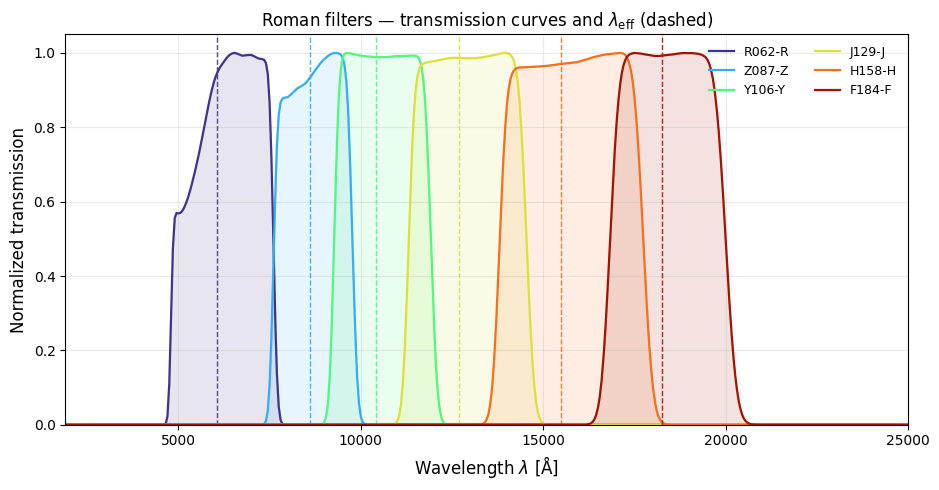

  R062-R      lambda_eff =   6044.8 Å
  Z087-Z      lambda_eff =   8604.8 Å
  Y106-Y      lambda_eff =  10409.2 Å
  J129-J      lambda_eff =  12692.5 Å
  H158-H      lambda_eff =  15494.9 Å
  F184-F      lambda_eff =  18243.6 Å


In [ ]:
import pyphot

# ── leer filtros Roman ────────────────────────────────────────────────────────
with fits.open('/Users/bhianca/kilonova/kcor/kcor_ROMAN.fits') as hdul:
    t = Table(hdul['FilterTrans'].data)

cols        = t.colnames
wave_aa     = np.array(t[cols[0]], dtype=float)
filter_cols = [c for c in cols[1:] if c != 'W146-W']

# ── construir filtros pyphot ──────────────────────────────────────────────────
results = {}
for col in filter_cols:
    resp = np.array(t[col], dtype=float)
    mi_filtro = pyphot.Filter(
        wave_aa * pyphot.config.units.U("AA"),
        resp,
        name=col,
        dtype="photon",
    )
    leff_quantity = mi_filtro.leff.to('AA')
    lambda_eff = float(getattr(leff_quantity, 'value', getattr(leff_quantity, 'magnitude', leff_quantity)))
    results[col] = {
        'filter': mi_filtro,
        'response': resp,
        'lambda_eff': lambda_eff,
    }

# ── plot transmissivity + lambda_eff ──────────────────────────────────────────
figure, axis = plt.subplots(figsize=(9.5, 5))
colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(filter_cols)))

for col, color in zip(filter_cols, colors):
    response = results[col]['response']
    lambda_eff = results[col]['lambda_eff']
    peak_response = response.max()
    normalized_response = response / peak_response if peak_response > 0 else response

    axis.plot(wave_aa, normalized_response, color=color, lw=1.6, label=col)
    axis.fill_between(wave_aa, 0, normalized_response, color=color, alpha=0.12)
    axis.axvline(lambda_eff, color=color, ls='--', lw=1.0, alpha=0.9)

axis.set_xlabel(r'Wavelength $\lambda$ [Å]', fontsize=12)
axis.set_ylabel('Normalized transmission', fontsize=12)
axis.set_title(r'Roman filters — transmission curves and $\lambda_{\rm eff}$ (dashed)', fontsize=12)
axis.set_xlim(wave_aa.min(), wave_aa.max())
axis.set_ylim(0, 1.05)
axis.legend(frameon=False, fontsize=9, ncol=2, loc='upper right')
axis.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('/Users/bhianca/Kilonova/data/dust_generation/roman_filter_transmissions.png', dpi=150, bbox_inches='tight')
plt.show()

for col in filter_cols:
    print(f'  {col:<10s}  lambda_eff = {results[col]["lambda_eff"]:8.1f} Å')


Magnitud Vega en R062-R: 29.968 mag
Magnitud Vega en Z087-Z: 28.132 mag
Magnitud Vega en Y106-Y: 27.265 mag
Magnitud Vega en J129-J: 26.852 mag
Magnitud Vega en H158-H: 26.340 mag
Magnitud Vega en F184-F: 26.163 mag


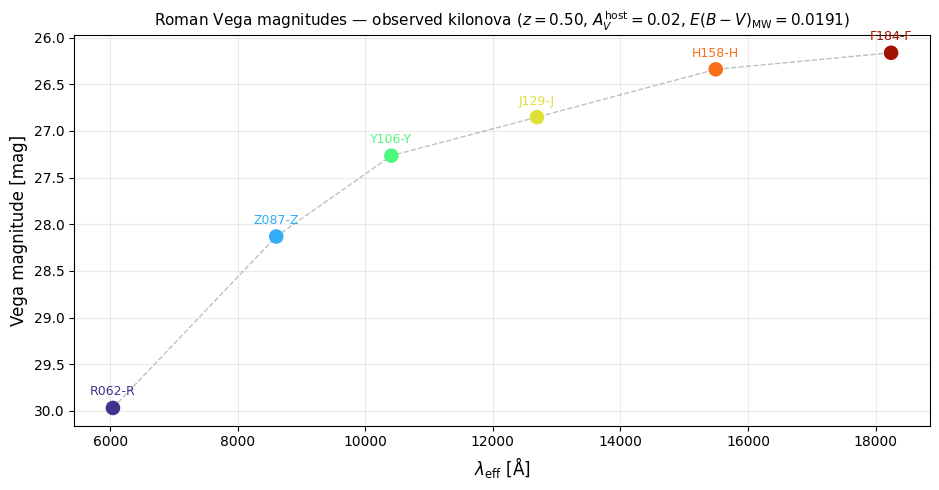

In [ ]:
from pyphot.vega import Vega
import pyphot


def plot_roman_vega_magnitudes(vega_magnitudes, observed_spectrum_result, save_path=None):
    parameters = observed_spectrum_result['parameters']
    filter_names = list(vega_magnitudes.keys())
    lambda_effs = [vega_magnitudes[col]['lambda_eff'] for col in filter_names]
    magnitudes = [vega_magnitudes[col]['magnitude'] for col in filter_names]

    sort_order = np.argsort(lambda_effs)
    filter_names_sorted = [filter_names[i] for i in sort_order]
    lambda_effs_sorted = [lambda_effs[i] for i in sort_order]
    magnitudes_sorted = [magnitudes[i] for i in sort_order]

    colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(filter_names_sorted)))

    figure, axis = plt.subplots(figsize=(9.5, 5))
    axis.scatter(lambda_effs_sorted, magnitudes_sorted, c=colors, s=90, zorder=3)
    axis.plot(lambda_effs_sorted, magnitudes_sorted, color='gray', lw=1.0, ls='--', alpha=0.5)

    for col, lambda_eff, mag, color in zip(filter_names_sorted, lambda_effs_sorted, magnitudes_sorted, colors):
        axis.annotate(
            col,
            (lambda_eff, mag),
            textcoords='offset points',
            xytext=(0, 9),
            ha='center',
            fontsize=9,
            color=color,
        )

    axis.set_xlabel(r'$\lambda_{\rm eff}$ [Å]', fontsize=12)
    axis.set_ylabel('Vega magnitude [mag]', fontsize=12)
    axis.set_title(
        fr'Roman Vega magnitudes — observed kilonova '
        fr'($z={parameters["redshift"]:.2f}$, '
        fr'$A_V^{{\rm host}}={parameters["extinction_av_host"]:.2f}$, '
        fr'$E(B-V)_{{\rm MW}}={parameters["ebv_milky_way"]:.4f}$)',
        fontsize=11,
    )
    axis.invert_yaxis()
    axis.grid(alpha=0.25)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def compute_roman_vega_magnitudes(observed_spectrum_result, roman_filters, plot=True, save_path=None):
    vega = Vega()

    wavelength_obs = observed_spectrum_result['wavelength_observed'].to(u.AA).value
    flux_obs = observed_spectrum_result['flux_observed'].to(FLUX_UNIT).value

    wave_with_units = wavelength_obs * pyphot.config.units.U("AA")
    flux_with_units = flux_obs * pyphot.config.units.U("flam")

    vega_magnitudes = {}
    for col, filter_data in roman_filters.items():
        f = filter_data['filter']
        fluxes = f.get_flux(wave_with_units, flux_with_units, axis=-1)
        mag = -2.5 * np.log10(fluxes.value) - f.Vega_zero_mag
        vega_magnitudes[col] = {
            'magnitude': mag,
            'lambda_eff': filter_data['lambda_eff'],
        }
        print(f"Magnitud Vega en {f.name}: {mag:0.3f} mag")

    if plot:
        plot_roman_vega_magnitudes(vega_magnitudes, observed_spectrum_result, save_path=save_path)

    return vega_magnitudes


roman_vega_magnitudes = compute_roman_vega_magnitudes(
    observed_spectrum_result,
    results,
    plot=True,
    save_path='/Users/bhianca/Kilonova/data/dust_generation/kn_roman_vega_magnitudes.png',
)


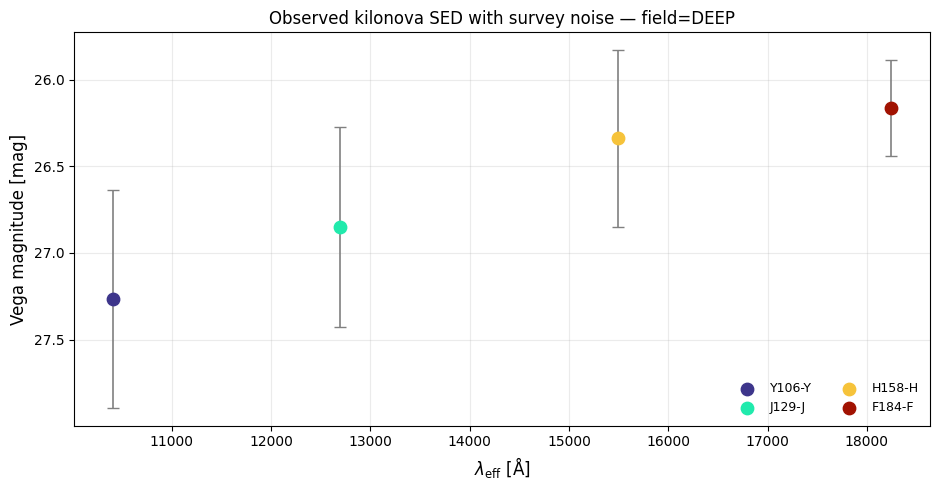

Field: DEEP
  Y106-Y      lambda_eff= 10409.2 Å  mag=27.2651  3 sigma_mag=0.62887  delta_mag=0.0001
  J129-J      lambda_eff= 12692.5 Å  mag=26.8525  3 sigma_mag=0.57616  delta_mag=0.0000
  H158-H      lambda_eff= 15494.9 Å  mag=26.3398  3 sigma_mag=0.50914  delta_mag=0.0000
  F184-F      lambda_eff= 18243.6 Å  mag=26.1629  3 sigma_mag=0.27674  delta_mag=0.0000


In [ ]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa


def plot_sigma_flux_lookup(filter_results, field):
    sorted_filters = sorted(filter_results.items(), key=lambda item: item[1]['lambda_eff'])
    filter_names = [key for key, _ in sorted_filters]
    lambda_effs = [data['lambda_eff'] for _, data in sorted_filters]
    magnitudes = [data['magnitude'] for _, data in sorted_filters]
    tres_sigma_mags = [data['sigma_mag'] * 3 for _, data in sorted_filters]

    colors = plt.cm.turbo(np.linspace(0.05, 0.95, len(filter_names)))

    figure, axis = plt.subplots(figsize=(9.5, 5))
    axis.errorbar(
        lambda_effs,
        magnitudes,
        yerr=tres_sigma_mags,
        fmt='none',
        ecolor='gray',
        elinewidth=1.2,
        capsize=4,
        zorder=2,
    )
    for lambda_eff, magnitude, sigma_mag, color, name in zip(lambda_effs, magnitudes, tres_sigma_mags, colors, filter_names):
        if np.isnan(sigma_mag):
            axis.scatter(lambda_eff, magnitude, color=color, s=80, marker='v', zorder=3, label=f'{name} (ND)')
        else:
            axis.scatter(lambda_eff, magnitude, color=color, s=80, zorder=3, label=name)

    axis.set_xlabel(r'$\lambda_{\rm eff}$ [Å]', fontsize=12)
    axis.set_ylabel('Vega magnitude [mag]', fontsize=12)
    axis.set_title(
        fr'Observed kilonova SED with survey noise — field={field}',
        fontsize=12,
    )
    axis.invert_yaxis()
    axis.legend(frameon=False, fontsize=9, ncol=2, loc='lower right')
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def lookup_sigma_flux(
    roman_vega_magnitudes,
    field,
    snr_min=5.0,
    photometry_path=HOURGLASS_PHOTOMETRY_PATH,
    objects_path=HOURGLASS_OBJECTS_PATH,
    plot=True,
):
    objects_arrow = pq.read_table(objects_path)
    cids_in_field = objects_arrow.filter(pc.equal(objects_arrow['field'], field))['cid'].to_pylist()

    photometry_arrow = pq.read_table(
        photometry_path,
        columns=['cid', 'band', 'sim_mag_obs', 'fluxcal', 'fluxcal_err'],
        filters=[('sim_mag_obs', '<', 90.0), ('fluxcal', '>', 0.0), ('fluxcal_err', '>', 0.0), ('cid', 'in', cids_in_field)],
    )

    filter_results = {}
    for filter_key, filter_data in roman_vega_magnitudes.items():
        target_magnitude = filter_data['magnitude']
        lambda_eff = filter_data['lambda_eff']
        band = filter_key[0]

        band_arrow = photometry_arrow.filter(pc.equal(photometry_arrow['band'], band))
        if len(band_arrow) == 0:
            continue
        snr = pc.divide(
            pc.cast(band_arrow['fluxcal'], pa.float64()),
            pc.cast(band_arrow['fluxcal_err'], pa.float64()),
        )
        band_arrow = band_arrow.filter(pc.greater_equal(snr, snr_min))
        sim_mag = np.array(pc.cast(band_arrow['sim_mag_obs'], pa.float64()).to_pylist())
        mag_limit = float(sim_mag.max())

        if target_magnitude > mag_limit:
            filter_results[filter_key] = {
                'magnitude': target_magnitude,
                'lambda_eff': lambda_eff,
                'sigma_mag': np.nan,
                'fluxcal': np.nan,
                'fluxcal_err': np.nan,
                'mag_limit': mag_limit,
                'detected': False,
            }
            continue

        closest_index = int(np.argmin(np.abs(sim_mag - target_magnitude)))
        fluxcal = float(band_arrow['fluxcal'][closest_index].as_py())
        fluxcal_err = float(band_arrow['fluxcal_err'][closest_index].as_py())
        sigma_mag = (2.5 / np.log(10)) * fluxcal_err / fluxcal
        delta_mag = float(np.abs(sim_mag[closest_index] - target_magnitude))

        filter_results[filter_key] = {
            'magnitude': target_magnitude,
            'lambda_eff': lambda_eff,
            'sigma_mag': sigma_mag,
            'fluxcal': fluxcal,
            'fluxcal_err': fluxcal_err,
            'mag_limit': mag_limit,
            'delta_mag': delta_mag,
            'detected': True,
        }

    if plot:
        plot_sigma_flux_lookup(filter_results, field)
        print(f'Field: {field}')
        for filter_key, data in sorted(filter_results.items(), key=lambda item: item[1]['lambda_eff']):
            if data['detected']:
                print(
                    f"  {filter_key:<10}  lambda_eff={data['lambda_eff']:>8.1f} Å  "
                    f"mag={data['magnitude']:>7.4f}  3 sigma_mag={3*data['sigma_mag']:.5f}  "
                    f"delta_mag={data['delta_mag']:.4f}"
                )
            else:
                print(
                    f"  {filter_key:<10}  lambda_eff={data['lambda_eff']:>8.1f} Å  "
                    f"mag={data['magnitude']:>7.4f}  NOT DETECTED (limit={data['mag_limit']:.4f})"
                )

    return filter_results


filter_results = lookup_sigma_flux(roman_vega_magnitudes, field='DEEP', plot=True)


  WIDE  J  n= 446,527
  WIDE  R  n= 283,474
  WIDE  Y  n= 446,120
  WIDE  Z  n= 345,268
  DEEP  F  n= 201,185
  DEEP  H  n= 198,819
  DEEP  J  n= 218,916
  DEEP  Y  n= 180,499


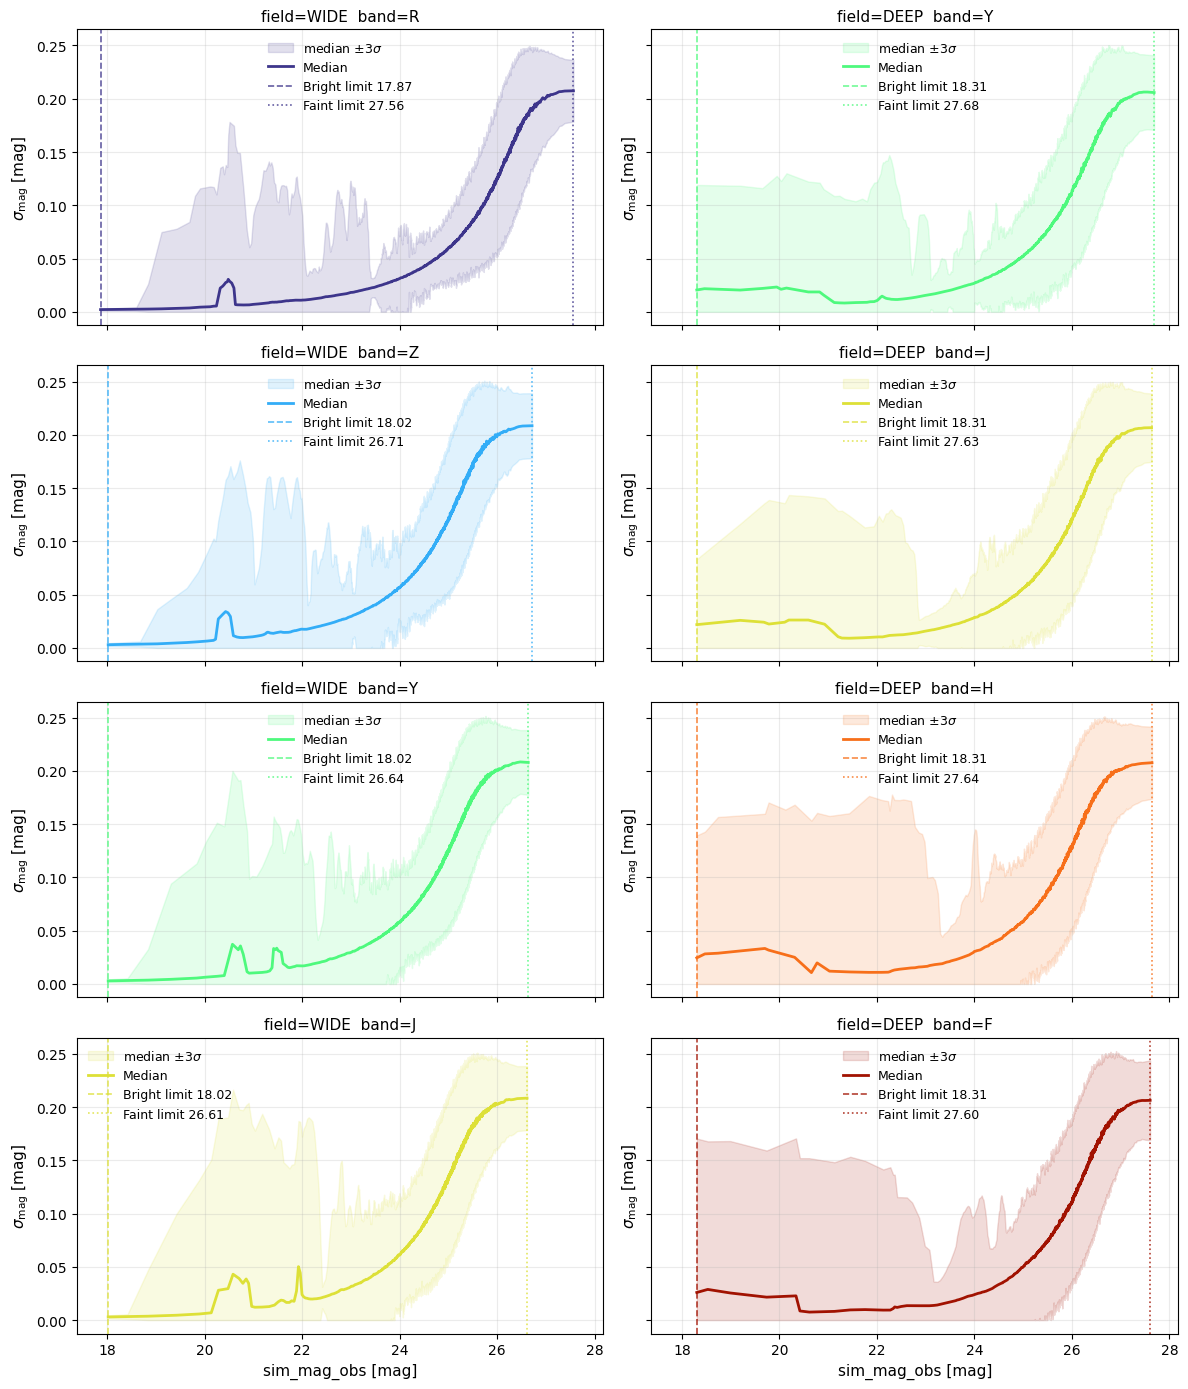

In [ ]:
BAND_ORDER = ['R', 'Z', 'Y', 'J', 'H', 'F']
BAND_COLORS = {
    band: plt.cm.turbo(position)
    for band, position in zip(BAND_ORDER, np.linspace(0.05, 0.95, len(BAND_ORDER)))
}


def _compute_band_stats(df, window=1000, plot_points=2000):
    sorted_df = df.sort_values('sim_mag_obs').reset_index(drop=True)
    magnitudes = sorted_df['sim_mag_obs'].to_numpy()
    sigma_series = pd.Series(sorted_df['sigma_mag'].to_numpy())

    rolling = sigma_series.rolling(window=window, center=True, min_periods=10)
    medians = rolling.median().to_numpy()
    stds = rolling.std().to_numpy()

    valid_mask = ~np.isnan(medians)
    magnitudes = magnitudes[valid_mask]
    medians = medians[valid_mask]
    stds = stds[valid_mask]

    step = max(1, len(magnitudes) // plot_points)
    magnitudes = magnitudes[::step]
    medians = medians[::step]
    stds = stds[::step]

    return (
        magnitudes,
        medians,
        np.maximum(medians - 3.0 * stds, 0.0),
        medians + 3.0 * stds,
    )


def plot_magnitude_vs_sigma(field_data):
    fields = list(field_data.keys())
    bands_per_field = {
        field: [band for band in BAND_ORDER if band in field_data[field]]
        for field in fields
    }
    number_of_rows = max(len(bands) for bands in bands_per_field.values())
    number_of_columns = len(fields)

    figure, axes = plt.subplots(
        number_of_rows, number_of_columns,
        figsize=(6.0 * number_of_columns, 3.5 * number_of_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for column_index, field in enumerate(fields):
        for row_index, band in enumerate(bands_per_field[field]):
            axis = axes[row_index][column_index]
            df = field_data[field][band]
            color = BAND_COLORS[band]
            bin_centers, medians, lower_3sigma, upper_3sigma = _compute_band_stats(df)

            mag_bright = float(bin_centers[0])
            mag_faint = float(bin_centers[-1])

            axis.fill_between(bin_centers, lower_3sigma, upper_3sigma, color=color, alpha=0.15, label=r'median $\pm 3\sigma$')
            axis.plot(bin_centers, medians, lw=2.0, color=color, label='Median')
            axis.axvline(mag_bright, color=color, lw=1.2, ls='--', alpha=0.8, label=f'Bright limit {mag_bright:.2f}')
            axis.axvline(mag_faint, color=color, lw=1.2, ls=':', alpha=0.8, label=f'Faint limit {mag_faint:.2f}')
            axis.set_ylabel(r'$\sigma_{\rm mag}$ [mag]', fontsize=11)
            axis.set_title(f'field={field}  band={band}', fontsize=11)
            axis.legend(frameon=False, fontsize=9)
            axis.grid(alpha=0.25)

        for row_index in range(len(bands_per_field[field]), number_of_rows):
            axes[row_index][column_index].set_visible(False)

    for column_index in range(number_of_columns):
        axes[-1][column_index].set_xlabel('sim_mag_obs [mag]', fontsize=11)

    plt.tight_layout()
    plt.show()


def analyze_magnitude_vs_sigma(
    fields=('WIDE', 'DEEP'),
    snr_min=5.0,
    photometry_path=HOURGLASS_PHOTOMETRY_PATH,
    objects_path=HOURGLASS_OBJECTS_PATH,
    plot=True,
):
    objects_arrow = pq.read_table(objects_path)
    field_data = {}

    for field in fields:
        cids_in_field = objects_arrow.filter(
            pc.equal(objects_arrow['field'], field)
        )['cid'].to_pylist()

        photometry_arrow = pq.read_table(
            photometry_path,
            columns=['band', 'sim_mag_obs', 'fluxcal', 'fluxcal_err'],
            filters=[
                ('sim_mag_obs', '<', 90.0),
                ('fluxcal', '>', 0.0),
                ('fluxcal_err', '>', 0.0),
                ('cid', 'in', cids_in_field),
            ],
        )
        photometry_df = photometry_arrow.to_pandas()
        photometry_df['sigma_mag'] = (2.5 / np.log(10)) * photometry_df['fluxcal_err'] / photometry_df['fluxcal']
        photometry_df = photometry_df[
            photometry_df['fluxcal'] / photometry_df['fluxcal_err'] >= snr_min
        ].reset_index(drop=True)

        band_frames = {}
        for band in sorted(photometry_df['band'].unique()):
            band_frames[band] = photometry_df[photometry_df['band'] == band].reset_index(drop=True)
            print(f'  {field}  {band}  n={len(band_frames[band]):>8,}')

        field_data[field] = band_frames

    if plot:
        plot_magnitude_vs_sigma(field_data)

    return field_data


field_data = analyze_magnitude_vs_sigma(fields=('WIDE', 'DEEP'), plot=True)


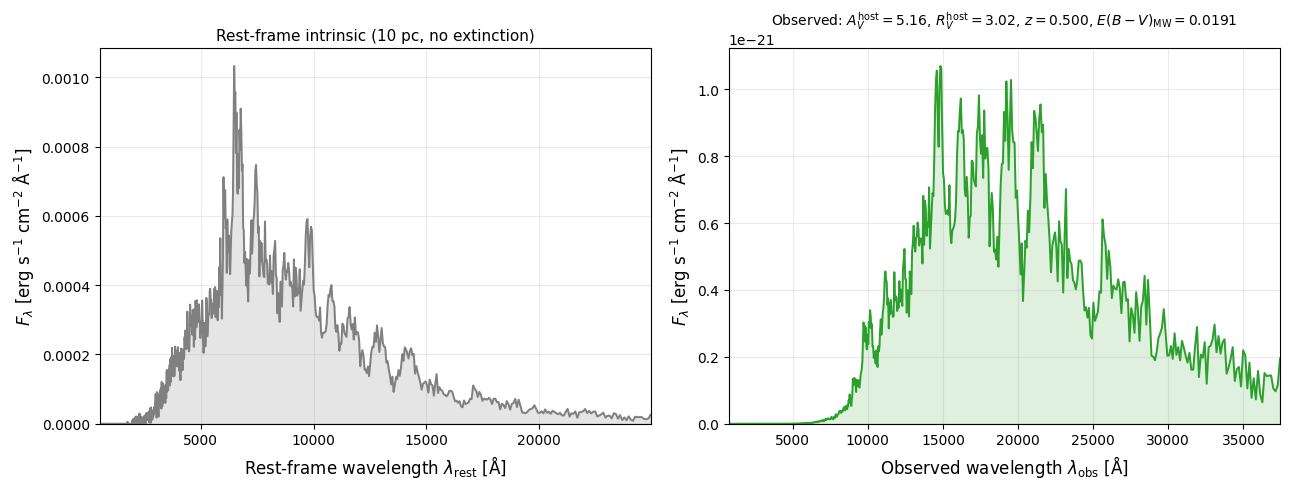

Host:      Av=5.163  Rv=3.021
Redshift:  z=0.5000  d_L=2.920e+09 pc
MW:        E(B-V)=0.0191  Av=0.0594  Rv=3.1
Magnitud Vega en R062-R: 36.456 mag
Magnitud Vega en Z087-Z: 32.542 mag
Magnitud Vega en Y106-Y: 30.699 mag
Magnitud Vega en J129-J: 29.312 mag
Magnitud Vega en H158-H: 28.128 mag
Magnitud Vega en F184-F: 27.531 mag


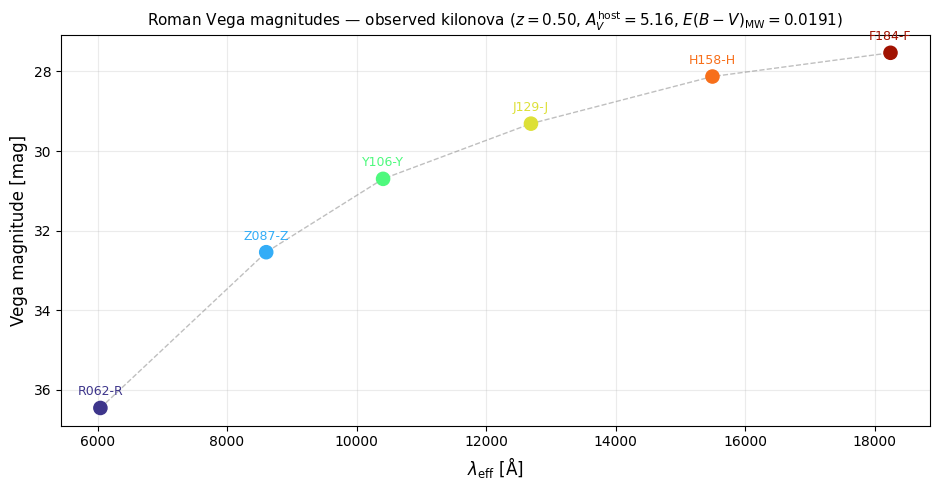

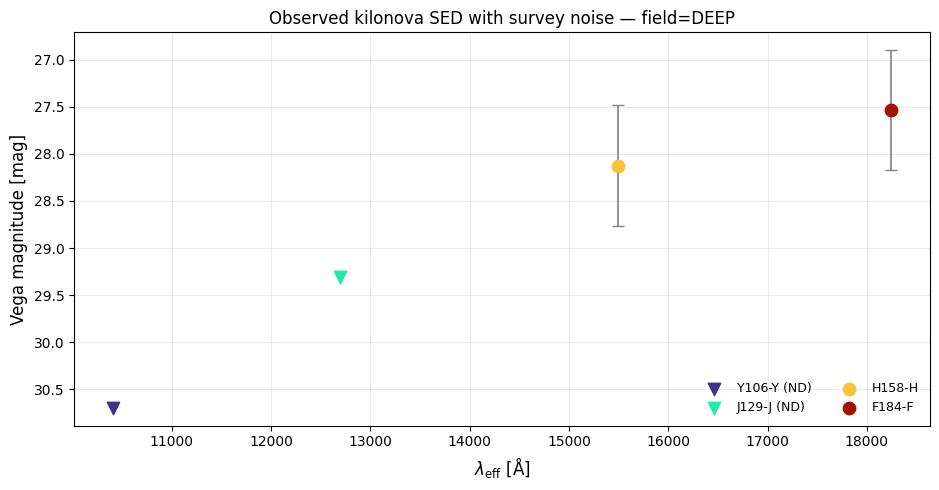

Field: DEEP
  Y106-Y      lambda_eff= 10409.2 Å  mag=30.6989  NOT DETECTED (limit=28.1539)
  J129-J      lambda_eff= 12692.5 Å  mag=29.3117  NOT DETECTED (limit=28.4259)
  H158-H      lambda_eff= 15494.9 Å  mag=28.1276  3 sigma_mag=0.64306  delta_mag=0.0448
  F184-F      lambda_eff= 18243.6 Å  mag=27.5315  3 sigma_mag=0.63427  delta_mag=0.0010


In [ ]:

def observe_kilonova_with_roman(
    model_wavelength,
    model_flux,
    field,
    redshift,
    av_samples,
    rv_samples,
    rv_milky_way=MILKY_WAY_RV,
    intrinsic_distance_parsec=10.0,
    snr_min=5.0,
    random_seed=7,
    plot=True,
):
    rng = np.random.default_rng(random_seed)
    extinction_av_host = float(rng.choice(av_samples))
    extinction_rv_host = float(rng.choice(rv_samples))

    hourglass_sampling = sample_hourglass_ebv(plot=False)
    ebv_milky_way = float(rng.choice(hourglass_sampling['ebv_samples']))

    observed_spectrum = generate_observed_kilonova_spectrum(
        wavelength_rest=model_wavelength,
        spectrum_input=model_flux,
        extinction_av_host=extinction_av_host,
        extinction_rv_host=extinction_rv_host,
        redshift=redshift,
        ebv_milky_way=ebv_milky_way,
        rv_milky_way=rv_milky_way,
        intrinsic_distance_parsec=intrinsic_distance_parsec,
        input_mode='flux',
        output_mode='flux',
        plot=plot,
    )

    vega_magnitudes = compute_roman_vega_magnitudes(
        observed_spectrum,
        results,
        plot=plot,
    )

    filter_results = lookup_sigma_flux(
        vega_magnitudes,
        field=field,
        snr_min=snr_min,
        plot=plot,
    )

    return filter_results


# ----

RV_samples = generate_rv_samples(number_of_samples=10000, plot=False)
Av_samples = generate_av_samples(
    number_of_samples=10000,
    exponential_scale=1.7,
    gaussian_sigma=0.6,
    plot=False)
single_redshift = 0.5


pipeline_results = observe_kilonova_with_roman(
    model_wavelength=wave_kn,
    model_flux=flux_kn,
    field='DEEP',
    redshift=single_redshift,
    av_samples=Av_samples,
    rv_samples=RV_samples,
    plot=True,
)


Loaded from /Users/bhianca/Kilonova/data/lanl_catalog.parquet  (3,301,884 spectra)


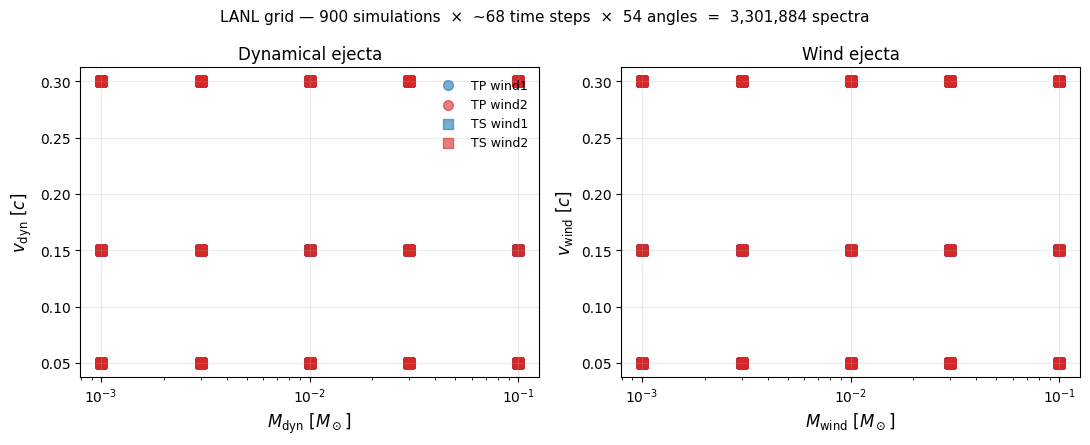

In [27]:
import re
import subprocess
import pandas as pd

LANL_GRID_DIR = Path("/Volumes/Elements/kilonova/LANL_grid/kn_sim_cube_v1")
LANL_CATALOG_PATH = Path("/Users/bhianca/Kilonova/data/lanl_catalog.parquet")

_SPEC_PATTERN = re.compile(
    r'Run_(T[PS])_dyn_all_lanth_(wind\d)_all_'
    r'md([\d.]+)_vd([\d.]+)_mw([\d.]+)_vw([\d.]+)_spec_'
)


def _read_header_times(filepath):
    result = subprocess.run(
        ['grep', '^#', filepath],
        capture_output=True, text=True, check=True,
    )
    return [float(line.split('time[d]=')[1]) for line in result.stdout.splitlines()]


def plot_lanl_catalog(catalog):
    file_catalog = catalog.drop_duplicates(subset='filepath')
    colors = {'wind1': 'C0', 'wind2': 'C3'}
    markers = {'TP': 'o', 'TS': 's'}

    figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for run_type in sorted(file_catalog['run_type'].unique()):
        for wind in sorted(file_catalog['wind'].unique()):
            subset = file_catalog[
                (file_catalog['run_type'] == run_type) & (file_catalog['wind'] == wind)
            ]
            axes[0].scatter(
                subset['mass_dynamical'], subset['velocity_dynamical'],
                color=colors[wind], marker=markers[run_type], alpha=0.6, s=50,
                label=f'{run_type} {wind}',
            )
            axes[1].scatter(
                subset['mass_wind'], subset['velocity_wind'],
                color=colors[wind], marker=markers[run_type], alpha=0.6, s=50,
            )
    for axis, xlabel, ylabel, title in zip(
        axes,
        [r'$M_{\rm dyn}\ [M_\odot]$', r'$M_{\rm wind}\ [M_\odot]$'],
        [r'$v_{\rm dyn}\ [c]$', r'$v_{\rm wind}\ [c]$'],
        ['Dynamical ejecta', 'Wind ejecta'],
    ):
        axis.set_xlabel(xlabel, fontsize=12)
        axis.set_ylabel(ylabel, fontsize=12)
        axis.set_title(title, fontsize=12)
        axis.set_xscale('log')
        axis.grid(alpha=0.25)
    axes[0].legend(frameon=False, fontsize=9)
    n_sims = catalog['simulation_id'].nunique()
    n_times = catalog.groupby('simulation_id')['time_index'].nunique().mean()
    figure.suptitle(
        f'LANL grid — {n_sims} simulations  ×  ~{n_times:.0f} time steps  ×  {N_ANGLE_BINS} angles'
        f'  =  {len(catalog):,} spectra',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def build_lanl_catalog(grid_directory=LANL_GRID_DIR, save_path=LANL_CATALOG_PATH, plot=True):
    file_rows = []
    for simulation_id, filepath in enumerate(sorted(Path(grid_directory).glob('*_spec_*.dat'))):
        match = _SPEC_PATTERN.search(filepath.name)
        if match is None:
            continue
        run_type, wind, md, vd, mw, vw = match.groups()
        times = _read_header_times(str(filepath))
        file_rows.append({
            'simulation_id': simulation_id,
            'run_type': run_type,
            'wind': wind,
            'mass_dynamical': float(md),
            'velocity_dynamical': float(vd),
            'mass_wind': float(mw),
            'velocity_wind': float(vw),
            'times': times,
            'filepath': str(filepath),
        })

    file_df = pd.DataFrame(file_rows)
    file_df['time_data'] = [list(enumerate(times)) for times in file_df['times']]
    time_df = file_df.drop(columns='times').explode('time_data').reset_index(drop=True)
    time_df['time_index'] = time_df['time_data'].apply(lambda entry: entry[0])
    time_df['time_days'] = time_df['time_data'].apply(lambda entry: entry[1])
    time_df = time_df.drop(columns='time_data')

    n_time_rows = len(time_df)
    catalog = time_df.loc[time_df.index.repeat(N_ANGLE_BINS)].reset_index(drop=True)
    catalog['angle_index'] = np.tile(np.arange(N_ANGLE_BINS), n_time_rows)
    catalog.index.name = 'spectrum_id'

    if save_path is not None:
        catalog.to_parquet(save_path, index=True)
        print(f'Saved to {save_path}')
    if plot:
        plot_lanl_catalog(catalog)
        print(f'Total spectra:  {len(catalog):,}')
        print(f'Simulations:    {catalog["simulation_id"].nunique()}')
        print(f'Time range:     {catalog["time_days"].min():.3f} – {catalog["time_days"].max():.3f} days')
        print(f'Angles:         {N_ANGLE_BINS}')
    return catalog


def load_lanl_catalog(catalog_path=LANL_CATALOG_PATH, grid_directory=LANL_GRID_DIR, plot=True):
    if Path(catalog_path).exists():
        catalog = pd.read_parquet(catalog_path)
        print(f'Loaded from {catalog_path}  ({len(catalog):,} spectra)')
        if plot:
            plot_lanl_catalog(catalog)
        return catalog
    return build_lanl_catalog(grid_directory=grid_directory, save_path=catalog_path, plot=plot)


catalog = load_lanl_catalog(plot=True)


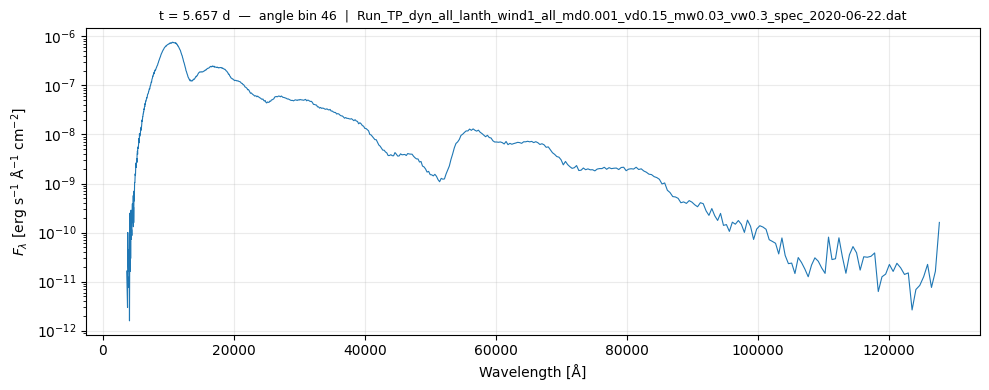

In [31]:
from pathlib import Path

CM_TO_ANG = (1 * u.cm).to(u.AA).value
Z_AT2017 = 0.009783
N_ANGLE_BINS = 54


def parse_spec(filepath):
    times, spectra, current = [], [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("#"):
                if current:
                    spectra.append(np.array(current))
                    current = []
                times.append(float(line.split("time[d]=")[1]))
            elif line:
                current.append([float(x) for x in line.split()])
    if current:
        spectra.append(np.array(current))
    spectra = np.array(spectra)
    lam_lo = spectra[0, :, 0] * CM_TO_ANG
    lam_hi = spectra[0, :, 1] * CM_TO_ANG
    lam_AA = 0.5 * (lam_lo + lam_hi)
    flux = spectra[:, :, 2:]
    return np.array(times), lam_AA, flux


def plot_lanl_spectrum(time_days, lam_AA, flux_lambda, angle_index, filepath=""):
    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(lam_AA, flux_lambda, lw=0.8, color='C0')
    axis.set_xlabel(r'Wavelength [Å]')
    axis.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ Å$^{-1}$ cm$^{-2}$]')
    axis.set_title(
        f't = {time_days:.3f} d  —  angle bin {angle_index}  |  {Path(filepath).name}',
        fontsize=9,
    )
    axis.set_yscale('log')
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def load_lanl_spectrum(spectrum_id, catalog_path=LANL_CATALOG_PATH, plot=True):
    catalog = pd.read_parquet(catalog_path)
    row = catalog.loc[spectrum_id]
    filepath = row['filepath']
    time_index = int(row['time_index'])
    angle_index = int(row['angle_index'])
    times, lam_AA, flux = parse_spec(filepath)
    spectrum = flux[time_index, :, angle_index]
    valid_mask = spectrum > 0
    lam_valid = lam_AA[valid_mask]
    spectrum_valid = spectrum[valid_mask]
    if plot:
        plot_lanl_spectrum(times[time_index], lam_valid, spectrum_valid, angle_index, filepath=filepath)
    return lam_valid, spectrum_valid


lam_valid, spectrum = load_lanl_spectrum(spectrum_id=100000, plot=True)


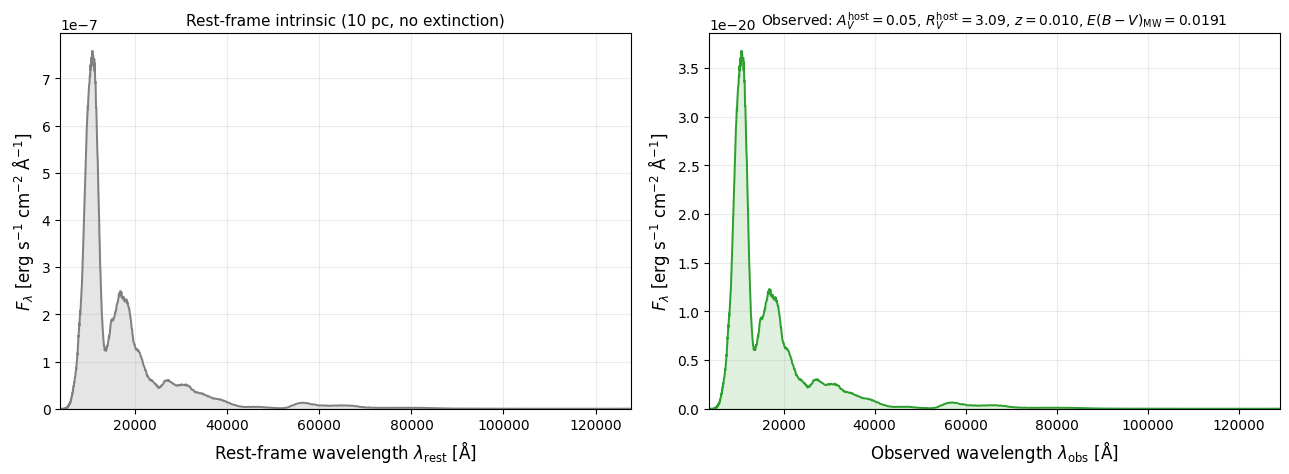

Host:      Av=0.050  Rv=3.090
Redshift:  z=0.0100  d_L=4.465e+07 pc
MW:        E(B-V)=0.0191  Av=0.0594  Rv=3.1
Magnitud Vega en R062-R: 30.087 mag
Magnitud Vega en Z087-Z: 26.766 mag
Magnitud Vega en Y106-Y: 25.544 mag
Magnitud Vega en J129-J: 25.749 mag
Magnitud Vega en H158-H: 25.322 mag
Magnitud Vega en F184-F: 24.697 mag


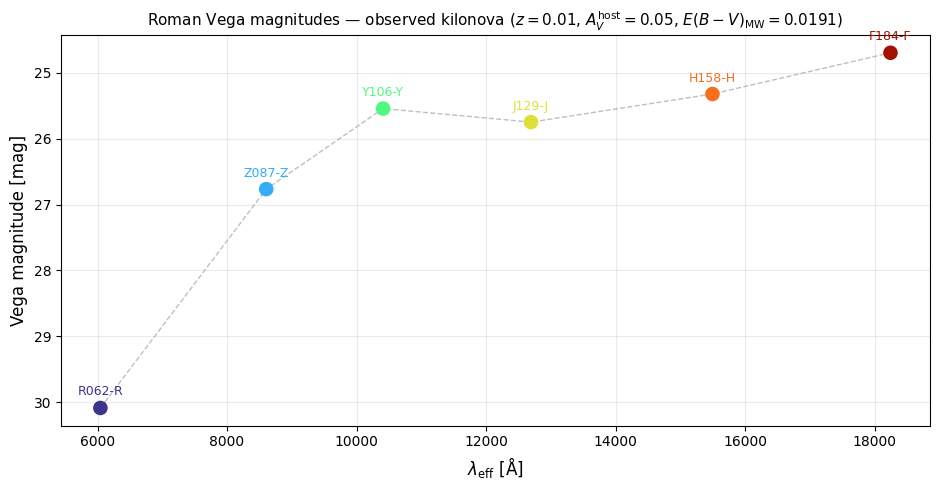

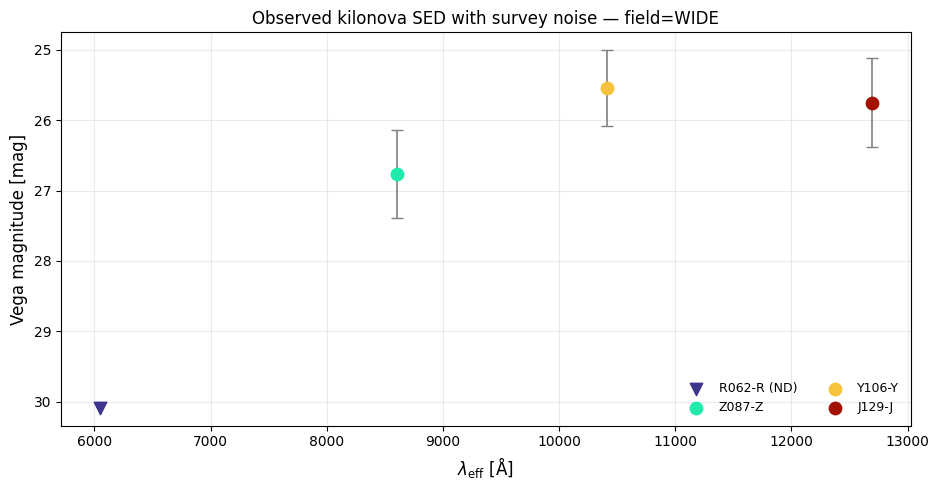

Field: WIDE
  R062-R      lambda_eff=  6044.8 Å  mag=30.0872  NOT DETECTED (limit=28.3785)
  Z087-Z      lambda_eff=  8604.8 Å  mag=26.7659  3 sigma_mag=0.62349  delta_mag=0.0030
  Y106-Y      lambda_eff= 10409.2 Å  mag=25.5438  3 sigma_mag=0.53916  delta_mag=0.0000
  J129-J      lambda_eff= 12692.5 Å  mag=25.7489  3 sigma_mag=0.63476  delta_mag=0.0000


In [38]:
pipeline_results = observe_kilonova_with_roman(
    model_wavelength=lam_valid,
    model_flux=spectrum,
    field='WIDE',
    redshift=0.01,
    av_samples=Av_samples,
    rv_samples=RV_samples,
    plot=True,
)

Magnitud Vega en R062-R: 22.326 mag
Magnitud Vega en Z087-Z: 22.628 mag
Magnitud Vega en Y106-Y: 22.849 mag
Magnitud Vega en J129-J: 22.969 mag
Magnitud Vega en H158-H: 23.087 mag
Magnitud Vega en F184-F: 23.123 mag
Magnitud Vega en R062-R: 22.183 mag
Magnitud Vega en Z087-Z: 22.493 mag
Magnitud Vega en Y106-Y: 22.719 mag
Magnitud Vega en J129-J: 22.848 mag
Magnitud Vega en H158-H: 22.916 mag
Magnitud Vega en F184-F: 22.985 mag
Magnitud Vega en R062-R: 22.068 mag
Magnitud Vega en Z087-Z: 22.379 mag
Magnitud Vega en Y106-Y: 22.602 mag
Magnitud Vega en J129-J: 22.731 mag
Magnitud Vega en H158-H: 22.815 mag
Magnitud Vega en F184-F: 22.899 mag
Magnitud Vega en R062-R: 21.958 mag
Magnitud Vega en Z087-Z: 22.297 mag
Magnitud Vega en Y106-Y: 22.497 mag
Magnitud Vega en J129-J: 22.640 mag
Magnitud Vega en H158-H: 22.731 mag
Magnitud Vega en F184-F: 22.801 mag
Magnitud Vega en R062-R: 21.856 mag
Magnitud Vega en Z087-Z: 22.212 mag
Magnitud Vega en Y106-Y: 22.416 mag
Magnitud Vega en J129-J: 22.

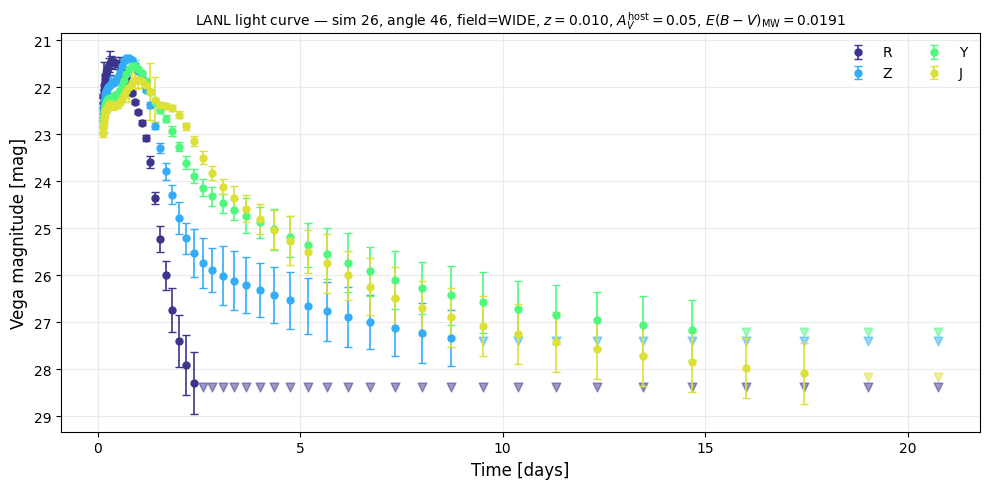

In [46]:
def plot_lanl_light_curve(
    time_days,
    band_photometry,
    simulation_id,
    angle_index,
    field,
    redshift,
    extinction_av_host,
    extinction_rv_host,
    ebv_milky_way,
):
    figure, axis = plt.subplots(figsize=(10, 5))

    for band in BAND_ORDER:
        if band not in band_photometry or not band_photometry[band]:
            continue
        color = BAND_COLORS[band]
        times_detected = []
        mags_detected = []
        sigmas_detected = []
        times_nondetected = []
        limits_nondetected = []

        for time_value, entry in zip(time_days, band_photometry[band]):
            if entry['detected']:
                times_detected.append(time_value)
                mags_detected.append(entry['magnitude'])
                sigmas_detected.append(3.0 * entry['sigma_mag'])
            else:
                times_nondetected.append(time_value)
                limits_nondetected.append(entry['mag_limit'])

        if times_detected:
            axis.errorbar(
                times_detected,
                mags_detected,
                yerr=sigmas_detected,
                fmt='o',
                color=color,
                markersize=5,
                lw=1.2,
                capsize=3,
                label=band,
            )
        if times_nondetected:
            axis.scatter(
                times_nondetected,
                limits_nondetected,
                color=color,
                marker='v',
                s=40,
                alpha=0.5,
            )

    axis.set_xlabel('Time [days]', fontsize=12)
    axis.set_ylabel('Vega magnitude [mag]', fontsize=12)
    axis.set_title(
        fr'LANL light curve — sim {simulation_id}, angle {angle_index}, field={field}, '
        fr'$z={redshift:.3f}$, $A_V^{{\rm host}}={extinction_av_host:.2f}$, '
        fr'$E(B-V)_{{\rm MW}}={ebv_milky_way:.4f}$',
        fontsize=10,
    )
    axis.invert_yaxis()
    axis.legend(frameon=False, fontsize=10, ncol=2)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def compute_lanl_light_curve(
    spectrum_id,
    field,
    redshift,
    av_samples,
    rv_samples,
    roman_filters,
    catalog_path=LANL_CATALOG_PATH,
    snr_min=5.0,
    consecutive_nondetection_limit=2,
    random_seed=7,
    plot=True,
):
    catalog = pd.read_parquet(catalog_path)
    reference_row = catalog.loc[spectrum_id]
    simulation_id = int(reference_row['simulation_id'])
    angle_index = int(reference_row['angle_index'])
    filepath = reference_row['filepath']

    rng = np.random.default_rng(random_seed)
    extinction_av_host = float(rng.choice(av_samples))
    extinction_rv_host = float(rng.choice(rv_samples))
    hourglass_sampling = sample_hourglass_ebv(plot=False)
    ebv_milky_way = float(rng.choice(hourglass_sampling['ebv_samples']))

    time_series = catalog[
        (catalog['simulation_id'] == simulation_id) &
        (catalog['angle_index'] == angle_index)
    ].sort_values('time_days').reset_index()

    times_file, lam_AA, flux = parse_spec(filepath)

    time_days_list = []
    band_photometry = {band: [] for band in BAND_ORDER}
    consecutive_nondetections = 0

    for _, row in time_series.iterrows():
        time_index = int(row['time_index'])
        spectrum = flux[time_index, :, angle_index]
        valid_mask = spectrum > 0
        lam_valid = lam_AA[valid_mask]
        spectrum_valid = spectrum[valid_mask]

        observed = generate_observed_kilonova_spectrum(
            wavelength_rest=lam_valid,
            spectrum_input=spectrum_valid,
            extinction_av_host=extinction_av_host,
            extinction_rv_host=extinction_rv_host,
            redshift=redshift,
            ebv_milky_way=ebv_milky_way,
            plot=False,
        )
        vega_mags = compute_roman_vega_magnitudes(observed, roman_filters, plot=False)
        filter_results = lookup_sigma_flux(vega_mags, field=field, snr_min=snr_min, plot=False)

        epoch_has_detection = any(data['detected'] for data in filter_results.values())
        if epoch_has_detection:
            consecutive_nondetections = 0
        else:
            consecutive_nondetections += 1

        time_days_list.append(float(row['time_days']))
        for band_key, data in filter_results.items():
            band = band_key[0]
            if band in band_photometry:
                band_photometry[band].append({
                    'magnitude': data['magnitude'],
                    'sigma_mag': data['sigma_mag'],
                    'mag_limit': data['mag_limit'],
                    'detected': data['detected'],
                })

        if consecutive_nondetections >= consecutive_nondetection_limit:
            print(
                f'Stopped at t={float(row["time_days"]):.3f} d '
                f'({consecutive_nondetection_limit} consecutive epochs with no detections)'
            )
            break

    if plot:
        plot_lanl_light_curve(
            time_days_list,
            band_photometry,
            simulation_id,
            angle_index,
            field,
            redshift,
            extinction_av_host,
            extinction_rv_host,
            ebv_milky_way,
        )

    return time_days_list, band_photometry


time_days_lc, band_photometry_lc = compute_lanl_light_curve(
    spectrum_id=100000,
    field='WIDE',
    redshift=0.01,
    av_samples=Av_samples,
    rv_samples=RV_samples,
    roman_filters=results,
    plot=True,
)
